### Data Loading

Load all log datasets and examine their formats.

In [28]:
# Library imports
import re # Import regex module for pattern matching (used for semantic type detection)
import time # Import time module to measure execution duration of operations
from pathlib import Path # Import Path class for datasets path handling
from collections import Counter # Import Counter for counting token frequencies
from datetime import datetime # Import datetime for timestamp parsing and conversion

# Try to import all required libraries - if any fail, install them
try:
    import pandas as pd # Import Pandas for Data manipulation and CSV export functionality
    import matplotlib.pyplot as plt  # Import Matplotlib for creating charts and visualizations
    import numpy as np # Import numpy for numerical operations and array handling
    import gzip # Import Gzip for baseline comparison
    import bz2 # Import bz2 for Bzip2 compression (baseline comparison)
    import lzma # Import lzma for LZMA compression (baseline comparison)
    import msgpack # Import msgpack for binary serialization format (efficient data packing)
    import zstandard as zstd  # Import zstandard for Facebook's Zstd compression

# If any import fails, install missing packages and retry
except ImportError:
    print("Installing dependencies...") # Notify that we're installing dependencies
    %pip install pandas numpy matplotlib msgpack zstandard # Use pip magic command to install required packages

    # Retry imports after installation
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np
    import msgpack
    import zstandard as zstd

# Create tables directory for CSV exports (for thesis results)
TABLES_DIR = Path("tables") # Create "tables" directory to store CSV output files
TABLES_DIR.mkdir(exist_ok=True) # Don't error if directory already exists

print("All libraries loaded.") # Confirm successful library loading


All libraries loaded.


In [29]:
# Dataset paths configuration
# These are LogHub log datasets from different systems for validating LogPress
# Each dataset represents different log formats and semantic patterns
DATASETS_DIR = Path("datasets")  # Directory containing all raw log files

# Dictionary mapping dataset names to file paths
# Diverse dataset selection addresses RQ3: What types of semantic information exist in logs?
# Each dataset has unique characteristics:
# - BGL: Blue Gene/L supercomputer logs (node IDs, timestamps, error codes)
# - Apache: Web server logs (HTTP requests, status codes, IPs)
# - Hadoop: Distributed computing logs (HDFS blocks, Java exceptions)
# - HealthApp: Healthcare app logs (user IDs, timestamps, activities)
# - Linux: System logs (kernel messages, auth events, hostnames)
# - Mac: macOS system logs (LaunchServices, security certificates, OIDs)
# - Openstack: Cloud infrastructure logs (API calls, UUIDs, service names)
# - Proxifier: Network proxy logs (connections, IPs, ports)
# - SSH: Secure shell logs (login attempts, IPs, authentication failures)
# - Zookeeper: Distributed coordination logs (state changes, leader election)
DATASET_FILES = {
    "BGL": DATASETS_DIR / "BGL.log",
    "Apache": DATASETS_DIR / "Apache.log",
    "Hadoop": DATASETS_DIR / "Hadoop.log",
    "HealthApp": DATASETS_DIR / "HealthApp.log",
    "Linux": DATASETS_DIR / "Linux.log",
    "Mac": DATASETS_DIR / "Mac.log",
    "Openstack": DATASETS_DIR / "Openstack.log",
    "Proxifier": DATASETS_DIR / "Proxifier.log",
    "SSH": DATASETS_DIR / "SSH.log",
    "Zookeeper": DATASETS_DIR / "Zookeeper.log",
}

print(f"Configured {len(DATASET_FILES)} datasets for LogPress evaluation")


Configured 10 datasets for LogPress evaluation


In [30]:
# Helper functions for log file stats

def load_log_file(filepath):
    try:
        # Open with UTF-8 encoding
        with open(filepath, 'r', encoding='utf-8', errors='replace') as f:
            # Strip newlines
            lines = [line.rstrip('\n') for line in f]
        return lines
    except FileNotFoundError:
        # To not crash if one dataset missing
        print(f"Warning: {filepath} not found")
        return []

def format_size(size_bytes):
    kb = size_bytes / 1024  # Convert bytes to kilobytes
    if kb < 1024:
        return f"{kb:.1f} KB"
    mb = kb / 1024  # Convert to megabytes if it over 1 MB
    if mb < 1024:
        return f"{mb:.1f} MB"
    gb = mb / 1024  # Convert to gigabytes if it is over 1 GB
    return f"{gb:.2f} GB"

print("Helper functions defined successfully")

Helper functions defined successfully


In [31]:
# Load all datasets into memory - Phase 1 of LogPress pipeline
# This is our baseline: original uncompressed log data

datasets = {}  # Store loaded log data: {dataset_name: [log_lines]}
stats = []     # Collect statistics for each dataset

print("Loading datasets...")
print("=" * 60)

# Process each configured dataset
for name, filepath in DATASET_FILES.items():
    # Load log lines using encoding handler
    lines = load_log_file(filepath)
    
    # Store in memory for processing phases
    datasets[name] = lines
    
    # Calculate original file size - NEEDED for compression ratio (RQ1)
    # Compression ratio = original_size / compressed_size
    # We need correct baseline sizes
    file_size = filepath.stat().st_size if filepath.exists() else 0
    
    # Collect stats for each dataset
    stats.append({
        "Dataset": name,                          # Dataset name
        "Log Count": len(lines),                  # Number of log entries (scale matters)
        "Total Size": format_size(file_size),     # Dataset size
        "Size (bytes)": file_size,                # Raw bytes
        "Avg Log Length": int(np.mean([len(l) for l in lines])) if lines else 0  # Avg chars/log
    })
    
    # Progress feedback
    print(f"{name:12} - {len(lines):>7,} logs, {format_size(file_size)}")

print("=" * 60)
print(f"Total datasets loaded: {len(datasets)}")

# Convert to DataFrame for easy manipulation and export
df_stats = pd.DataFrame(stats)
print("\nDataset Statistics:")
print(df_stats.to_string(index=False))

# Save statistics
df_stats.to_csv(TABLES_DIR / "dataset_loading_stats.csv", index=False)



Loading datasets...
BGL          - 826,284 logs, 111.0 MB
Apache       -  51,978 logs, 4.7 MB
Hadoop       - 179,993 logs, 30.4 MB
HealthApp    - 253,395 logs, 22.4 MB
Linux        -  25,567 logs, 2.2 MB
Mac          - 117,283 logs, 16.1 MB
Openstack    - 189,386 logs, 53.4 MB
Proxifier    -  21,320 logs, 2.4 MB
SSH          - 655,147 logs, 70.0 MB
Zookeeper    -  74,273 logs, 9.9 MB
Total datasets loaded: 10

Dataset Statistics:
  Dataset  Log Count Total Size  Size (bytes)  Avg Log Length
      BGL     826284   111.0 MB     116443333             139
   Apache      51978     4.7 MB       4975683              94
   Hadoop     179993    30.4 MB      31887283             176
HealthApp     253395    22.4 MB      23529930              90
    Linux      25567     2.2 MB       2349686              90
      Mac     117283    16.1 MB      16879552             141
Openstack     189386    53.4 MB      56005960             294
Proxifier      21320     2.4 MB       2519391             117
      SS

In [32]:
# Preview log formats from each dataset
# This analysis helps understand semantic diversity for RQ3
# Each dataset has unique structure, vocabulary, and semantic patterns

print("Log Format Examples")
print("=" * 80)

for name, lines in datasets.items():
    print(f"\n{name} Dataset:")
    print("-" * 80)
    # Show first 3 logs to understand as a sample
    for i, log in enumerate(lines[:3], 1):
        # Truncate very long logs (for example Hadoop logs exceed 500 chars)
        display_log = log if len(log) <= 120 else log[:117] + "..."
        print(f"  {i}. {display_log}")
    
    # Indicate if there are more logs
    if len(lines) > 3:
        print(f"  ... ({len(lines) - 3:,} more logs)")

print("=" * 80)


Log Format Examples

BGL Dataset:
--------------------------------------------------------------------------------
  1. - 1117838570 2005.06.03 R02-M1-N0-C:J12-U11 2005-06-03-15.42.50.363779 R02-M1-N0-C:J12-U11 RAS KERNEL INFO instructio...
  2. - 1117838570 2005.06.03 R02-M1-N0-C:J12-U11 2005-06-03-15.42.50.527847 R02-M1-N0-C:J12-U11 RAS KERNEL INFO instructio...
  3. - 1117838570 2005.06.03 R02-M1-N0-C:J12-U11 2005-06-03-15.42.50.675872 R02-M1-N0-C:J12-U11 RAS KERNEL INFO instructio...
  ... (826,281 more logs)

Apache Dataset:
--------------------------------------------------------------------------------
  1. [Thu Jun 09 06:07:04 2005] [notice] LDAP: Built with OpenLDAP LDAP SDK
  2. [Thu Jun 09 06:07:04 2005] [notice] LDAP: SSL support unavailable
  3. [Thu Jun 09 06:07:04 2005] [notice] suEXEC mechanism enabled (wrapper: /usr/sbin/suexec)
  ... (51,975 more logs)

Hadoop Dataset:
--------------------------------------------------------------------------------
  1. 2015-10-17 21:

In [33]:
# Calculate log statistics

log_stats = []  # Collect detailed statistics for each dataset

for name, lines in datasets.items():
    if not lines:  # Skip empty datasets (shouldn't happen, but its defensive mechanism)
        continue
    
    # Characters analysis
    lengths = [len(line) for line in lines]
    
    # Token analysis
    token_counts = [len(line.split()) for line in lines]
    
    # Collect statistics for analysis
    log_stats.append({
        "Dataset": name,
        "Log Count": len(lines),                    # Scale matters for compression
        "Min Length": min(lengths),                 # Shortest log (chars)
        "Max Length": max(lengths),                 # Longest log (chars)
        "Avg Length": int(np.mean(lengths)),        # Average log length (chars)
        "Median Length": int(np.median(lengths)),   # Median log length (chars)
        "Avg Tokens": round(np.mean(token_counts), 1),  # Average tokens per log
        "Total Chars": sum(lengths),                # Total characters (baseline size)
    })

# Create DataFrame for analysis and export
df_log_stats = pd.DataFrame(log_stats)

print("Detailed Log Statistics:")
print("=" * 100)
print(df_log_stats.to_string(index=False))
print("=" * 100)

# Save tables - these statistics support our RQ3 discussion
df_log_stats.to_csv(TABLES_DIR / "log_statistics.csv", index=False)
print(f"\nSaved log statistics to {TABLES_DIR}/log_statistics.csv")


Detailed Log Statistics:
  Dataset  Log Count  Min Length  Max Length  Avg Length  Median Length  Avg Tokens  Total Chars
      BGL     826284         100         477         139            139        12.5    115617049
   Apache      51978          48         187          94             98        12.9      4923706
   Hadoop     179993          65         592         176            187        14.1     31707290
HealthApp     253395          48         294          90             87         3.3     23023140
    Linux      25567          29        1030          90             74        12.0      2324119
      Mac     117283           1        1314         141            124        13.0     16634140
Openstack     189386         100         450         294            314        20.6     55816574
Proxifier      21320          91         224         117            110        13.7      2498071
      SSH     655147          65         188         110             97        13.9     72107214
Zooke

### Tokenization

Split logs into tokens. 
Tokenizer will handle those delimiters ( Spaces, Brackets [] () , Pipes | , Colons : , Equals = ).
Count Token Frequency and Distribution per dataset.

In [34]:
# Tokenization Function with Separators
# This is Phase 2 of LogPress: Tokenization

PRESERVE_PATTERNS = [
    # Timestamp formats - will be encoded later on using delta for compression
    r'\d{8}-\d{2}:\d{2}:\d{2}:\d{3}',  # YYYYMMDD-HH:MM:SS:mmm (Hadoop, HealthApp formats)
    r'\d{2}:\d{2}:\d{2}[.,]\d{3}',     # HH:MM:SS.mmm or HH:MM:SS,mmm (Linux, Openstack)
    r'\d{2}:\d{2}:\d{2}',              # HH:MM:SS without milliseconds (Mac, SSH)
    
    # IP addresses  
    r'\b(?:0|[1-9]\d{0,2})\.(?:0|[1-9]\d{0,2})\.(?:0|[1-9]\d{0,2})\.(?:0|[1-9]\d{0,2}):\d+\b',  # IP:port
    r'\b(?:0|[1-9]\d{0,2})\.(?:0|[1-9]\d{0,2})\.(?:0|[1-9]\d{0,2})\.(?:0|[1-9]\d{0,2})\b',       # IP only
    
    # Hostnames with hyphens and numbers 
    # Examples: calvisitor-10-105-160-95, server-01, app-prod-2
    r'\b[a-zA-Z][a-zA-Z0-9]*(?:-[a-zA-Z0-9]+)+\b',  
]



# Each pattern wrapped in group
PRESERVE_REGEX = re.compile('|'.join(f'({p})' for p in PRESERVE_PATTERNS))



def tokenize_with_separators(log):
    # Split log into tokens while preserving separators.
    # This is the BASICS of LogPress's lossless compression approach.
    # We keep the exact separator information (spaces, tabs, symbols) so we can reconstruct the original log after decompression.
    
    #Returns:
    #    tokens: List of semantic units (words, IPs, timestamps etc..)
    #    separators: List of separators between tokens (whitespace, delimiters)

    tokens = []      # Semantic units that will be classified and compressed
    separators = []  # Exact separators for reconstruction
    
    # Define delimiter categories
    bracket_delims = "[](){}"  # Brackets become tokens themselves (common in structured logs)
    symbol_delims = "|:=,"     # Symbols split tokens
    whitespace = " \t"         # Space and tab separate tokens
    
    # First pass: Find all patterns and their positions
    # This prevents timestamps like "10:05:25" from being split on colons
    preserved = []  # List of (start_pos, end_pos, matched_text) tuples
    for match in PRESERVE_REGEX.finditer(log):
        preserved.append((match.start(), match.end(), match.group()))
    
    # Helper to check if a position is inside a preserved pattern
    def is_preserved(pos):
        # Check if character position is within a preserved pattern
        for start, end, _ in preserved:
            if start <= pos < end:
                return True
        return False
    
    current_token = ""  # Accumulate characters for current token
    current_sep = ""    # Accumulate separator characters
    i = 0               # Current position in log string
    
    # Main tokenization loop - process log character by character
    while i < len(log):
        char = log[i]
        
        # Check if we're at the start of a preserved pattern
        for start, end, text in preserved:
            if i == start:
                # Save any pending token before adding preserved pattern
                if current_token:
                    tokens.append(current_token)
                    separators.append(current_sep)
                    current_token = ""
                    current_sep = ""
                
                # Add the entire preserved pattern as token
                # Example: "192.168.1.1" stays together, not split into "192" "." "168" etc.
                tokens.append(text)
                separators.append(current_sep)
                current_sep = ""
                i = end  # Jump past the entire preserved pattern
                break
        else:
            if char in whitespace:
                # Whitespace delimits tokens
                if current_token:
                    tokens.append(current_token)
                    separators.append(current_sep)
                    current_token = ""
                    current_sep = char  # Start new separator
                else:
                    current_sep += char  # Continue accumulating separator
            elif char in bracket_delims or char in symbol_delims:
                # Delimiters become tokens themselves
                if current_token:
                    tokens.append(current_token)
                    separators.append(current_sep)
                    current_token = ""
                    current_sep = ""
                # The delimiter itself becomes a token
                tokens.append(char)
                separators.append(current_sep)
                current_sep = ""
            else:
                current_token += char
            i += 1
    
    # Handle any remaining token at end of log
    if current_token:
        tokens.append(current_token)
        separators.append(current_sep)
    elif current_sep:
        separators.append(current_sep)
    
    return tokens, separators


In [35]:
# Define all semantic type codes for column storage
TYPE_TIMESTAMP = 0      # Timestamps
TYPE_SEVERITY = 1       # Severity levels
TYPE_IP_ADDRESS = 2     # IPv addresses
TYPE_PORT = 3           # Port numbers 
TYPE_PROCESS_ID = 4     # Process IDs
TYPE_PATH = 5           # File paths and URLs
TYPE_HEX = 6            # Hexadecimal values
TYPE_UUID = 7           # UUIDs
TYPE_MAC_ADDRESS = 8    # MAC addresses
TYPE_NUMBER = 9         # Generic numbers
TYPE_WORD = 10          # Generic words
TYPE_WORD_ID = 11       # Dictionary-encoded words
TYPE_OTHER = 12         # Unclassified tokens
TYPE_HOSTNAME = 13      # Server identification
TYPE_USERNAME = 14      # User/account tracking
TYPE_ERROR_CODE = 15    # Application errors
TYPE_REQUEST_ID = 16    # Request/transaction IDs
TYPE_SEPARATOR = 17     # Punctuation/delimiters (:, [, ], =, -, |)
TYPE_MODULE = 18        # packages
TYPE_COMPONENT = 19     # Service/module names 

# Reverse mapping for display
TYPE_NAME_TO_CODE = {
    'TIMESTAMP': TYPE_TIMESTAMP,
    'SEVERITY': TYPE_SEVERITY,
    'IP_ADDRESS': TYPE_IP_ADDRESS,
    'PORT': TYPE_PORT,
    'PROCESS_ID': TYPE_PROCESS_ID,
    'PATH': TYPE_PATH,
    'HEX': TYPE_HEX,
    'UUID': TYPE_UUID,
    'MAC_ADDRESS': TYPE_MAC_ADDRESS,
    'NUMBER': TYPE_NUMBER,
    'WORD': TYPE_WORD,
    'WORD_ID': TYPE_WORD_ID,
    'OTHER': TYPE_OTHER,
    'HOSTNAME': TYPE_HOSTNAME,
    'USERNAME': TYPE_USERNAME,
    'ERROR_CODE': TYPE_ERROR_CODE,
    'REQUEST_ID': TYPE_REQUEST_ID,
    'SEPARATOR': TYPE_SEPARATOR,
    'MODULE': TYPE_MODULE,
    'COMPONENT': TYPE_COMPONENT
}

# Mapping: type code to type name string (classify_token)
TYPE_CODE_TO_NAME = {
    TYPE_TIMESTAMP: 'TIMESTAMP',
    TYPE_SEVERITY: 'SEVERITY',
    TYPE_IP_ADDRESS: 'IP_ADDRESS',
    TYPE_PORT: 'PORT',
    TYPE_PROCESS_ID: 'PROCESS_ID',
    TYPE_PATH: 'PATH',
    TYPE_HEX: 'HEX',
    TYPE_UUID: 'UUID',
    TYPE_MAC_ADDRESS: 'MAC_ADDRESS',
    TYPE_NUMBER: 'NUMBER',
    TYPE_WORD: 'WORD',
    TYPE_WORD_ID: 'WORD_ID',
    TYPE_OTHER: 'OTHER',
    TYPE_HOSTNAME: 'HOSTNAME',
    TYPE_USERNAME: 'USERNAME',
    TYPE_ERROR_CODE: 'ERROR_CODE',
    TYPE_REQUEST_ID: 'REQUEST_ID',
    TYPE_SEPARATOR: 'SEPARATOR',
    TYPE_MODULE: 'MODULE',
    TYPE_COMPONENT: 'COMPONENT'
}

print(f"Defined {len(TYPE_NAME_TO_CODE)} semantic type codes")
print(f"\nType Codes:")
for name, code in sorted(TYPE_NAME_TO_CODE.items(), key=lambda x: x[1]):
    print(f"  {code:2d} - {name}")

Defined 20 semantic type codes

Type Codes:
   0 - TIMESTAMP
   1 - SEVERITY
   2 - IP_ADDRESS
   3 - PORT
   4 - PROCESS_ID
   5 - PATH
   6 - HEX
   7 - UUID
   8 - MAC_ADDRESS
   9 - NUMBER
  10 - WORD
  11 - WORD_ID
  12 - OTHER
  13 - HOSTNAME
  14 - USERNAME
  15 - ERROR_CODE
  16 - REQUEST_ID
  17 - SEPARATOR
  18 - MODULE
  19 - COMPONENT


In [36]:
# Define classification patterns with priorities
# Format: (type_code, regex_pattern, priority)
# ALL patterns use ^...$ to match ENTIRE token (not just start)
CLASSIFICATION_PATTERNS = [ 
    (TYPE_SEPARATOR, r'^[:\[\]=\-|(){}<>,;.!?/\\]+$', 105),  # :, [, ], =, -, |, (, ).
     
    (TYPE_TIMESTAMP, r'^\d{4}-\d{2}-\d{2}-\d{2}\.\d{2}\.\d{2}\.\d{6}$', 102),  # 2005-06-03-15.42.50.363779
    (TYPE_TIMESTAMP, r'^\d{8}-\d{2}:\d{2}:\d{2}:\d{3}$', 101),            # YYYYMMDD-HH:MM:SS:mmm
    (TYPE_TIMESTAMP, r'^\d{4}-\d{2}-\d{2}[T\s]\d{2}:\d{2}:\d{2}', 100),  # ISO8601 (partial match for longer)
    (TYPE_TIMESTAMP, r'^\d{4}-\d{2}-\d{2}$', 100),                        # 2015-10-17, 2017-05-16
    (TYPE_TIMESTAMP, r'^\w{3}\s+\d{1,2}\s+\d{2}:\d{2}:\d{2}$', 100),      # Syslog: Jan 30 10:05:25
    (TYPE_TIMESTAMP, r'^\d{2}:\d{2}:\d{2}[.,]\d{3}$', 100),               # HH:MM:SS.mmm or HH:MM:SS,mmm
    (TYPE_TIMESTAMP, r'^\d{2}:\d{2}:\d{2}$', 100),                        # HH:MM:SS
    (TYPE_TIMESTAMP, r'^\d{4}\.\d{2}\.\d{2}$', 99),                       # 2005.06.14
    (TYPE_TIMESTAMP, r'^\d{6}$', 98),                                     # HHMMSS: 081109
    (TYPE_TIMESTAMP, r'^(Mon|Tue|Wed|Thu|Fri|Sat|Sun)$', 97),            # Day names
    (TYPE_TIMESTAMP, r'^(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)$', 97),  # Month names
    
    # Priority 95: UUIDs and MAC addresses
    (TYPE_UUID, r'^[0-9a-fA-F]{8}-[0-9a-fA-F]{4}-[0-9a-fA-F]{4}-[0-9a-fA-F]{4}-[0-9a-fA-F]{12}$', 95),
    (TYPE_MAC_ADDRESS, r'^(?:[0-9a-fA-F]{2}[:-]){5}[0-9a-fA-F]{2}$', 95),
    
    # Priority 92: Module/Package names  
    (TYPE_MODULE, r'^(?:[a-z][a-z0-9_]*\.){2,}[a-zA-Z][a-zA-Z0-9_]*$', 92),   
    (TYPE_MODULE, r'^[a-z][a-z0-9_-]*\.[a-z][a-z0-9_-]*\.[a-z][a-z0-9_-]*', 92),  
    (TYPE_MODULE, r'^[A-Z][a-zA-Z0-9]*@\d+$', 91), 

    # Priority 90: IP Addresses 
    (TYPE_IP_ADDRESS, r'^(?:\d{1,3}\.){3}\d{1,3}(?::\d+)?$', 90),  
 
    # Priority 85: Severity Levels 
    (TYPE_SEVERITY, r'^(?:DEBUG|TRACE|INFO|NOTICE|WARN|WARNING|ERROR|ERR|CRITICAL|CRIT|FATAL|ALERT|EMERGENCY|SEVERE)$', 85),
    
    # Priority 82: Hostnames  
    (TYPE_HOSTNAME, r'^[A-Z][A-Z0-9_-]*$', 82), 
    (TYPE_HOSTNAME, r'^[a-z][a-z0-9_-]*$', 82), 
    (TYPE_HOSTNAME, r'^[A-Z][a-zA-Z0-9_-]*$', 82), 
    (TYPE_HOSTNAME, r'^server-\d+$', 82),
    (TYPE_HOSTNAME, r'^app-[a-z]+-\d+$', 82),
    
    # Priority 81: Usernames  
    (TYPE_USERNAME, r'^[a-z][a-z0-9_-]*\.exe$', 82),  # chrome.exe, firefox.exe
    (TYPE_USERNAME, r'^(?:admin|root|user)$', 81), 
    
    # Priority 80: Error codes and Request IDs  
    (TYPE_ERROR_CODE, r'^E\d{3,4}$', 80),
    (TYPE_ERROR_CODE, r'^(?:TIMEOUT|ECONNREFUSED|ENOTFOUND|EACCES|EPERM)$', 80),
    (TYPE_REQUEST_ID, r'^req-[a-f0-9]{8}-[a-f0-9]{4}-[a-f0-9]{4}-[a-f0-9]{4}-[a-f0-9]{12}$', 80),  # req-UUID format only
    
    # Priority 78: Paths and URLs
    (TYPE_PATH, r'^https?://[^\s]+$', 78),
    (TYPE_PATH, r'^(?:/[\w.-]+)+/?$', 78),
    (TYPE_PATH, r'^[a-zA-Z]:\\\\', 78),  # Windows paths
    (TYPE_PATH, r'^[a-z0-9_-]+\.log(?:\.\d+)?(?:\.\d{4}-\d{2}-\d{2}_)?$', 77),  # nova-compute.log.1.2017-05-17_
    
    # Priority 75: Numbers with context
    (TYPE_PORT, r'^port\s+\d{1,5}$', 75),
    (TYPE_PROCESS_ID, r'^\[\d+\]$', 75),
    (TYPE_NUMBER, r'^\d+(?:\.\d+)?%$', 74),
    (TYPE_NUMBER, r'^\d+(?:\.\d+)?\s*(?:B|KB|MB|GB|TB)$', 74),
    (TYPE_NUMBER, r'^\d+\.\d+\.\d+$', 73),  # Version numbers: 1.4.1
    
    # Priority 70: Hex values
    (TYPE_HEX, r'^0x[0-9a-fA-F]+$', 70),
    (TYPE_HEX, r'^[0-9a-fA-F]{8,}$', 69),
    
    # Priority 60: Generic numbers
    (TYPE_NUMBER, r'^-?\d+\.\d+$', 60),  # Floats
    (TYPE_NUMBER, r'^-?\d+$', 59),  # Integers 
    
    # Priority 50: Generic words 
    (TYPE_WORD, r'^[a-zA-Z_][a-zA-Z0-9_-]*\.$', 51), 
    (TYPE_WORD, r'^[a-zA-Z_][a-zA-Z0-9_-]*$', 50),
]

# Compile all patterns for efficient matching
compiled_patterns = [(type_code, re.compile(pattern), priority) 
                     for type_code, pattern, priority in CLASSIFICATION_PATTERNS]

# Sort by priority (highest first) for correct matching order
compiled_patterns.sort(key=lambda x: x[2], reverse=True)

print(f"Loaded {len(CLASSIFICATION_PATTERNS)} classification patterns")
print(f"Compiled and sorted by priority (highest first)")

Loaded 44 classification patterns
Compiled and sorted by priority (highest first)


In [37]:
    # Reconstruct original log from tokens and separators
    # This validates our core claim: LogPress provides lossless compression.
    # Any mismatch means data corruption.
    # This is stricter than other log parsers that only preserve semantics.

def reconstruct_from_tokens(tokens, separators):

    result = ""
    for i, token in enumerate(tokens):
        if i < len(separators):
            result += separators[i]  # Add separator before token
        result += token              # Add the token itself
    if len(separators) > len(tokens):
        result += separators[-1]
    return result


In [38]:
# Tokenize all datasets - Phase 2 of LogPress pipeline
# Transform raw logs into structured token sequences ready for semantic analysis

tokenized_datasets = {}  # Store {dataset_name: list of (tokens, separators) tuples}
tokenization_stats = []  # Collect statistics for analysis

print("Tokenizing all datasets...")
print("=" * 60)

for name, lines in datasets.items():
    if not lines:  # Skip empty datasets
        continue
    
    # Tokenize each log line
    tokenized_logs = []  # Store (tokens, separators) pairs for this dataset
    total_tokens = 0     # Track total token count for statistics
    
    for log in lines:
        # Apply tokenization with preserved patterns
        tokens, separators = tokenize_with_separators(log)
        tokenized_logs.append((tokens, separators))
        total_tokens += len(tokens)
    
    # Store tokenized data for Phase 3 (semantic classification)
    tokenized_datasets[name] = tokenized_logs
    
    # Calculate tokenization statistics
    avg_tokens = total_tokens / len(lines) if lines else 0
    
    tokenization_stats.append({
        "Dataset": name,
        "Logs": len(lines),
        "Total Tokens": total_tokens,
        "Avg Tokens/Log": round(avg_tokens, 1),
        "Token Density": round(total_tokens / sum(len(l) for l in lines) * 100, 1)
    })
    
    print(f"{name:12} - {len(lines):>7,} logs → {total_tokens:>9,} tokens")

print("=" * 60)

# Convert to DataFrame for analysis
df_tokenization = pd.DataFrame(tokenization_stats)
print("\nTokenization Statistics:")
print(df_tokenization.to_string(index=False))

# Save for thesis - tokenization overhead is part of performance analysis
df_tokenization.to_csv(TABLES_DIR / "tokenization_stats.csv", index=False)
print(f"\nSaved tokenization stats to {TABLES_DIR}/tokenization_stats.csv")


Tokenizing all datasets...
BGL          - 826,284 logs → 14,104,400 tokens
Apache       -  51,978 logs → 1,004,978 tokens
Hadoop       - 179,993 logs → 3,536,477 tokens
HealthApp    - 253,395 logs → 3,398,215 tokens
Linux        -  25,567 logs →   500,848 tokens
Mac          - 117,283 logs → 2,613,142 tokens
Openstack    - 189,386 logs → 5,402,464 tokens
Proxifier    -  21,320 logs →   466,682 tokens
SSH          - 655,147 logs → 15,814,737 tokens
Zookeeper    -  74,273 logs → 1,540,185 tokens

Tokenization Statistics:
  Dataset   Logs  Total Tokens  Avg Tokens/Log  Token Density
      BGL 826284      14104400            17.1           12.2
   Apache  51978       1004978            19.3           20.4
   Hadoop 179993       3536477            19.6           11.2
HealthApp 253395       3398215            13.4           14.8
    Linux  25567        500848            19.6           21.6
      Mac 117283       2613142            22.3           15.7
Openstack 189386       5402464           

In [39]:
# Analyze token frequency distribution

print("Analyzing token frequencies...")

all_tokens = []  # Collect all tokens from all datasets

for name, tokenized_logs in tokenized_datasets.items():
    for tokens, _ in tokenized_logs:
        all_tokens.extend(tokens)

# Count token frequencies
token_freq = Counter(all_tokens)
total_tokens = len(all_tokens)
unique_tokens = len(token_freq)

print(f"\nToken Frequency Analysis:")
print(f"  Total tokens: {total_tokens:,}")
print(f"  Unique tokens: {unique_tokens:,}")
print(f"  Redundancy: {(1 - unique_tokens/total_tokens)*100:.1f}%")

# Show most common tokens
print(f"\nTop 20 Most Frequent Tokens:")
print("-" * 60)
top_tokens = token_freq.most_common(20)
for i, (token, count) in enumerate(top_tokens, 1):
    pct = (count / total_tokens) * 100
    # Truncate very long tokens for display
    display_token = token if len(token) <= 30 else token[:27] + "..."
    print(f"  {i:2}. {display_token:32} - {count:>8,} times ({pct:>5.2f}%)")

# Save token frequency data
token_freq_data = [{
    "Rank": i,
    "Token": token,
    "Frequency": count,
    "Percentage": round((count/total_tokens)*100, 3)
} for i, (token, count) in enumerate(top_tokens, 1)]

df_token_freq = pd.DataFrame(token_freq_data)
df_token_freq.to_csv(TABLES_DIR / "token_frequency_top20.csv", index=False)
print(f"\nSaved to {TABLES_DIR}/token_frequency_top20.csv")


Analyzing token frequencies...

Token Frequency Analysis:
  Total tokens: 48,382,128
  Unique tokens: 1,827,566
  Redundancy: 96.2%

Top 20 Most Frequent Tokens:
------------------------------------------------------------
   1. :                                - 4,839,990 times (10.00%)
   2. [                                - 1,695,400 times ( 3.50%)
   3. ]                                - 1,694,357 times ( 3.50%)
   4. =                                - 1,682,473 times ( 3.48%)
   5. -                                - 1,503,028 times ( 3.11%)
   6. sshd                             -  873,498 times ( 1.81%)
   7. RAS                              -  826,157 times ( 1.71%)
   8. KERNEL                           -  819,834 times ( 1.69%)
   9. |                                -  766,241 times ( 1.58%)
  10. INFO                             -  665,796 times ( 1.38%)
  11. LabSZ                            -  655,147 times ( 1.35%)
  12. 0                                -  647,891 times (

### Semantic Type Detection

Classify tokens into semantic types using regex patterns.

The semanic types:

- TIMESTAMP: Date and time values
- IP_ADDRESS: IPv4 and IPv6 addresses
- SEVERITY: Log levels (INFO, WARN, ERROR, DEBUG, FATAL)
- NUMBER: Numeric values (integers, floats, hex)
- PATH: File paths and URLs
- PROCESS_ID: Process identifiers
- COMPONENT: Module and class names
- WORD: Regular words

In [40]:
SEMANTIC_PATTERNS = [
    # Convert from (type_code, pattern, priority) to (type_name, pattern, priority)
    (TYPE_CODE_TO_NAME.get(type_code, "OTHER"), pattern, priority)
    for type_code, pattern, priority in CLASSIFICATION_PATTERNS
]

# Pre-compile all patterns
COMPILED_PATTERNS = [(name, re.compile(pattern), priority) 
                     for name, pattern, priority in SEMANTIC_PATTERNS]

# Sort by priority (highest first)
COMPILED_PATTERNS.sort(key=lambda x: x[2], reverse=True)

### Classify tokens for all datasets


In [41]:
# Token classification functions - Phase 3 implementation
# Classify tokens into semantic types for optimized encoding

def classify_token(token):
    # Classify a single token into its semantic type using priority-based matching
    # This is where LogPress's magic happens. Unlike generic compressors
    # that treat all strings equally, we understand WHAT each token represents:
    # - IP addresses can be packed into 4 bytes
    # - Timestamps can be delta-encoded
    # - Numbers can use variable length encoding
    # The priority system works this way:
    # - "INFO" could match WORD pattern, but SEVERITY has higher priority
    # - "123" could match PROCESS_ID, but if it's part of timestamp, that wins
    
    
    # Try each compiled pattern
    for type_name, pattern, priority in COMPILED_PATTERNS:
        if pattern.match(token):  # Does this pattern match?
            # If this match has higher priority than current best, update
            return type_name
    
    # Default fallback
    return "OTHER"

#    Classify all tokens in a list, returning (token, type) pairs 

#    Example:
#    tokens = ["192.168.1.1", "failed", "5"]
#    types  = ["IP_ADDRESS", "WORD", "PROCESS_ID"]
#    List : create (token, type) tuple for each token

def classify_tokens(tokens):
    return [(token, classify_token(token)) for token in tokens]


classified_datasets = {}
separator_datasets = {}  # Store separators separately for reconstruction

print("Classifying tokens for all datasets...\n")

for name, tokenized_logs in tokenized_datasets.items():
    start = time.time()
    classified_logs = []
    separator_logs = []
    
    
    for tokens, seps in tokenized_logs:
        classified_logs.append(classify_tokens(tokens))
        separator_logs.append(seps)
    
    elapsed = time.time() - start
    
    classified_datasets[name] = classified_logs
    separator_datasets[name] = separator_logs  # Store separators for later use
    print(f"{name}: {len(classified_logs):,} logs classified in {elapsed:.2f}s")

print("\nClassification complete.")

Classifying tokens for all datasets...

BGL: 826,284 logs classified in 35.47s
Apache: 51,978 logs classified in 1.98s
Hadoop: 179,993 logs classified in 7.57s
HealthApp: 253,395 logs classified in 9.00s
Linux: 25,567 logs classified in 1.00s
Mac: 117,283 logs classified in 6.48s
Openstack: 189,386 logs classified in 14.32s
Proxifier: 21,320 logs classified in 1.29s
SSH: 655,147 logs classified in 37.62s
Zookeeper: 74,273 logs classified in 5.31s

Classification complete.


Semantic Type Distribution by Dataset:

Dataset     HEX         HOSTNAME    IP_ADDRESS  MODULE      NUMBER      OTHER       PATH        SEPARATOR   SEVERITY    TIMESTAMP   USERNAME    UUID        WORD        
------------------------------------------------------------------------------------------------------------------------------------------------------------------------
BGL         1,016,608   7,459,829   3,395       0           129,076     416,943     2,833       2,589,290   826,352     1,652,649   0           0           7,425       
Apache      0           310,579     31,090      0           124,815     8,339       39,458      330,091     0           155,934     0           0           4,672       
Hadoop      59,671      1,302,069   9,661       186,045     318,857     84,364      2,824       925,277     180,483     361,074     0           0           106,152     
HealthApp   305,957     391,543     5           16,861      609,438     197,195     50          1,359,496   0      

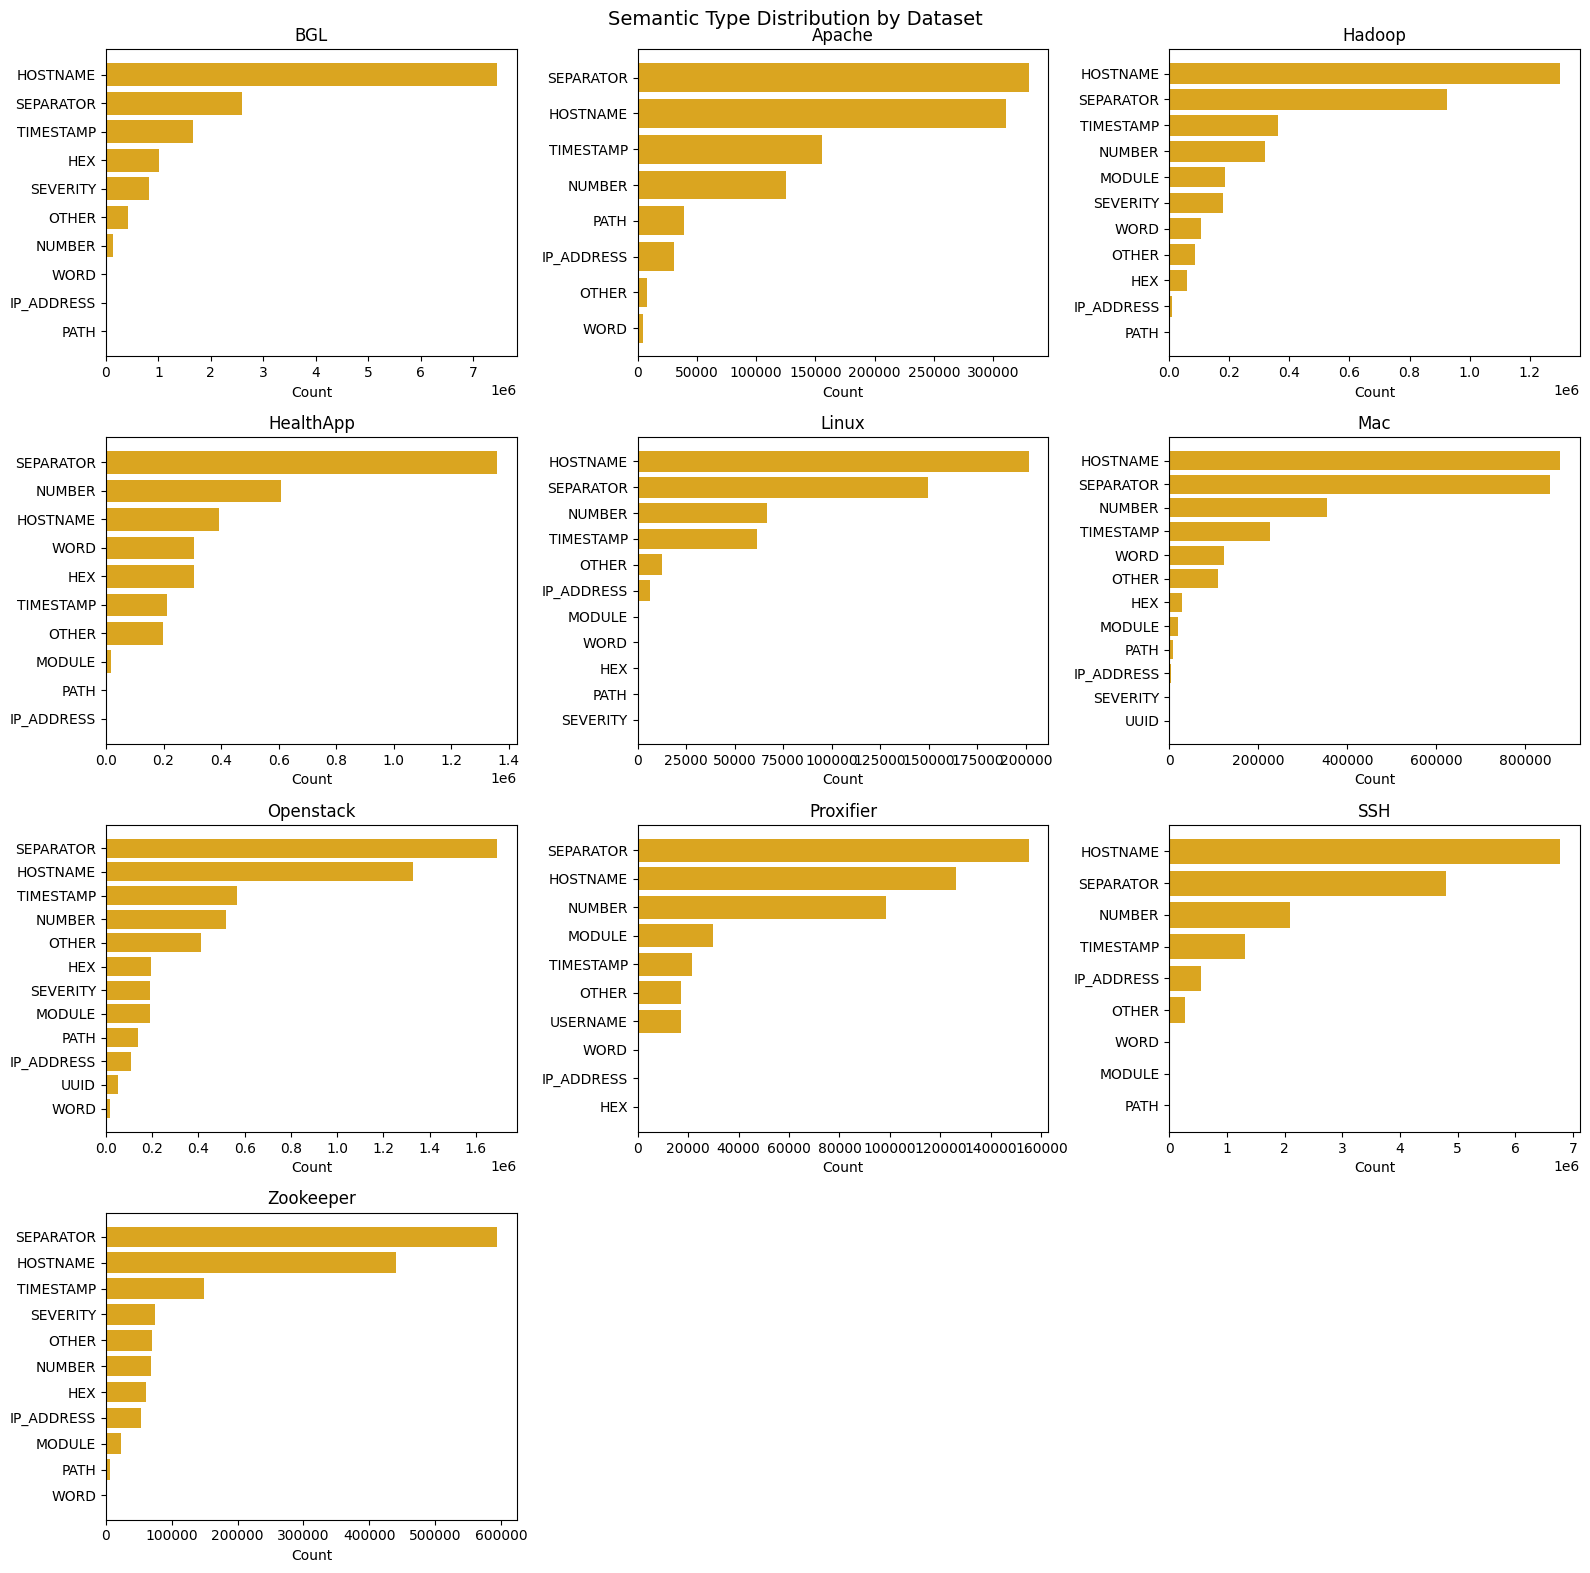

In [42]:
# Analyze semantic type distribution for all datasets and visualize results as a summary table and bar chart
type_distributions = {}

for name, classified_logs in classified_datasets.items():
    type_counts = Counter()
    for log in classified_logs:
        for token, token_type in log:
            type_counts[token_type] += 1
    type_distributions[name] = type_counts

# Create summary table
all_types = set()
for counts in type_distributions.values():
    all_types.update(counts.keys())
all_types = sorted(all_types)

print("Semantic Type Distribution by Dataset:\n")
header = f"{'Dataset':<12}" + "".join(f"{t:<12}" for t in all_types)
print(header)
print("-" * len(header))

# Build data for CSV
semantic_type_rows = []
for name in type_distributions:
    row = f"{name:<12}"
    row_data = {"Dataset": name}
    for t in all_types:
        count = type_distributions[name].get(t, 0)
        row += f"{count:<12,}"
        row_data[t] = count
    print(row)
    semantic_type_rows.append(row_data)

# Save to CSV
df_semantic = pd.DataFrame(semantic_type_rows)
df_semantic.to_csv(TABLES_DIR / "semantic_type_distribution.csv", index=False)
print(f"\nSaved to {TABLES_DIR}/semantic_type_distribution.csv")

# Visualize as bar charts
num_datasets = len(type_distributions)
cols = 3
rows = (num_datasets + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()

for idx, name in enumerate(type_distributions.keys()):
    ax = axes[idx]
    counts = type_distributions[name]
    
    sorted_types = sorted(counts.items(), key=lambda x: x[1], reverse=True)
    types = [t[0] for t in sorted_types]
    values = [t[1] for t in sorted_types]
    
    ax.barh(types, values, color="goldenrod")
    ax.set_xlabel("Count")
    ax.set_title(f"{name}")
    ax.invert_yaxis()

for idx in range(num_datasets, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Semantic Type Distribution by Dataset", fontsize=14)
plt.tight_layout()
plt.savefig('plots/semantic_type_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [43]:
# Show classification examples from each dataset
print("Classification Examples:\n")

for name, classified_logs in classified_datasets.items():
    if len(classified_logs) > 0:
        sample_log = classified_logs[0]
        original_log = datasets[name][0]
        
        print(f"{name} ===")
        print(f"Original: {original_log[:100]}..." if len(original_log) > 100 else f"Original: {original_log}")
        print("Classified tokens:")
        for token, token_type in sample_log[:10]:
            print(f"  {token_type:<12} : {token}")
        if len(sample_log) > 10:
            print(f"  ... and {len(sample_log) - 10} more tokens")
        print()

Classification Examples:

BGL ===
Original: - 1117838570 2005.06.03 R02-M1-N0-C:J12-U11 2005-06-03-15.42.50.363779 R02-M1-N0-C:J12-U11 RAS KERNE...
Classified tokens:
  SEPARATOR    : -
  HEX          : 1117838570
  TIMESTAMP    : 2005.06.03
  HOSTNAME     : R02-M1-N0-C
  SEPARATOR    : :
  HOSTNAME     : J12-U11
  TIMESTAMP    : 2005-06-03-15.42.50.363779
  HOSTNAME     : R02-M1-N0-C
  SEPARATOR    : :
  HOSTNAME     : J12-U11
  ... and 8 more tokens

Apache ===
Original: [Thu Jun 09 06:07:04 2005] [notice] LDAP: Built with OpenLDAP LDAP SDK
Classified tokens:
  SEPARATOR    : [
  TIMESTAMP    : Thu
  TIMESTAMP    : Jun
  NUMBER       : 09
  TIMESTAMP    : 06:07:04
  NUMBER       : 2005
  SEPARATOR    : ]
  SEPARATOR    : [
  HOSTNAME     : notice
  SEPARATOR    : ]
  ... and 7 more tokens

Hadoop ===
Original: 2015-10-17 21:48:16,337 INFO [main] org.apache.hadoop.metrics2.impl.MetricsConfig: loaded properties...
Classified tokens:
  TIMESTAMP    : 2015-10-17
  TIMESTAMP    : 21:48:16

### Schema and template extraction

The algorithm looks at each token in a log and checks if it changes (like timestamps, IPs, numbers) or stays the same (like brackets, keywords).
Variable tokens are replaced with placeholders like `<TIMESTAMP>`, while constant tokens stay as it is, creating a template that groups similar logs together.

In [44]:
# Define semantic types are that variable (replaced with placeholders) and which are constant (kept in template)

VARIABLE_TYPES = {
    "TIMESTAMP",      # Dates and times - always variable
    "IP_ADDRESS",     # IP addresses - always variable
    "PROCESS_ID",     # Process IDs - always variable
    "NUMBER",         # Numbers - always variable
    "HEX",           # Hex values - always variable
    "BLOCK_ID",      # Block IDs - always variable
    "PATH",          # File paths - always variable
    "UUID",          # UUIDs - always variable
    "MAC_ADDRESS",   # MAC addresses - always variable
    "KEY_VALUE",     # Key-value pairs - always variable
    "QUOTED_STRING", # Quoted strings - always variable
    "PORT",          # Port numbers - always variable
    "ERROR_CODE",    # Error codes - variable
}

CONSTANT_TYPES = {
    "SEVERITY",      # Log levels (INFO, ERROR) - keep in template
    "WORD",          # Regular words - keep in template
    "COMPONENT",     # Components - keep in template
    "SEPARATOR",     # Punctuation - keep in template (:, [, ], =, -)
    "HOSTNAME",      # Hostnames (sshd, KERNEL, RAS, LabSZ) - CONSTANT! They repeat frequently
    "MODULE",        # Module/class names repeat frequently (org.apache.hadoop.*, nova.compute.*)
    "USERNAME",      # With restricted patterns, chrome.exe, admin, root - stay in template
    "REQUEST_ID",    # With restricted patterns (req-UUID), stay in template
    "OTHER",         # Unclassified - keep in template
}


def extract_template(classified_log):
    template_tokens = []
    
    for token, token_type in classified_log:
        if token_type in VARIABLE_TYPES:
            template_tokens.append(f"<*{token_type}*>")
        else:
            template_tokens.append(token)
    
    return tuple(template_tokens)


def template_to_string(template):
    return " ".join(template)

In [45]:
# Extract templates 
template_datasets = {}

print("Extracting templates for all datasets...\n")
print(f"{'Dataset':<12} {'Logs':>12} {'Unique Templates':>18}")
print("-" * 45)

for name, classified_logs in classified_datasets.items():
    start = time.time()
    
    templates = []
    for log in classified_logs:
        template = extract_template(log)
        templates.append(template)
    
    unique_templates = len(set(templates))
    elapsed = time.time() - start
    
    template_datasets[name] = templates
    
    print(f"{name:<12} {len(templates):>12,} {unique_templates:>18,}")

print("\nTemplate extraction complete.")

Extracting templates for all datasets...

Dataset              Logs   Unique Templates
---------------------------------------------
BGL               826,284            330,687
Apache             51,978                 49
Hadoop            179,993             28,125
HealthApp         253,395             61,929
Linux              25,567              1,071
Mac               117,283             19,070
Openstack         189,386            121,180
Proxifier          21,320              2,117
SSH               655,147              5,780
Zookeeper          74,273                164

Template extraction complete.


Template Analysis:

Dataset        Total Logs    Templates  Logs/Template   Top Template
--------------------------------------------------------------------
BGL               826,284      330,687            2.5          18.4%
Apache             51,978           49         1060.8          38.7%
Hadoop            179,993       28,125            6.4           3.0%
HealthApp         253,395       61,929            4.1           7.0%
Linux              25,567        1,071           23.9          34.8%
Mac               117,283       19,070            6.2           3.0%
Openstack         189,386      121,180            1.6           2.7%
Proxifier          21,320        2,117           10.1          19.7%
SSH               655,147        5,780          113.3          21.3%
Zookeeper          74,273          164          452.9          14.0%

Saved to tables/template_analysis.csv


Top 5 Templates per Dataset:

BGL ===
  1. (152,182 logs, 18.4%) KERNDTLB <*HEX*> <*TIMESTAMP*> R30-M0-N9-C : J

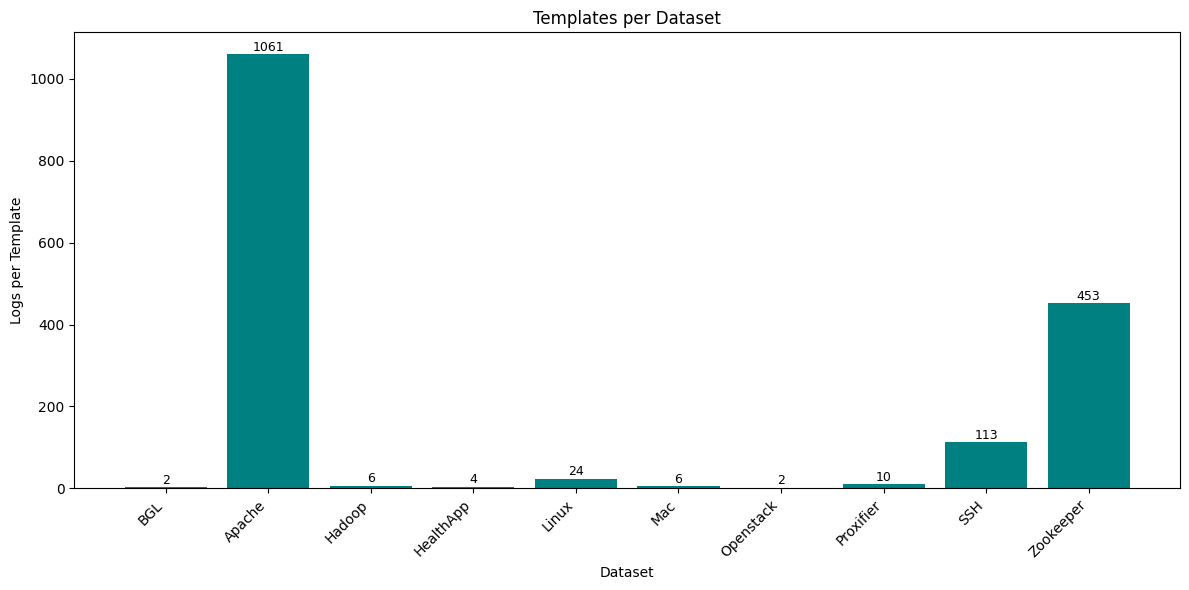

In [46]:
# Analyze template statistics
template_stats = {}

print("Template Analysis:\n")
print(f"{'Dataset':<12} {'Total Logs':>12} {'Templates':>12} {'Logs/Template':>14} {'Top Template':>14}")
print("-" * 68)

template_analysis_rows = []
for name, templates in template_datasets.items():
    template_counts = Counter(templates)
    total_logs = len(templates)
    num_templates = len(template_counts)
    
    # Compression ratio: how many logs share each template on average
    logs_per_template = total_logs / num_templates
    
    # Top template: what % of logs use the most common template
    top_template_count = template_counts.most_common(1)[0][1]
    top_template_pct = (top_template_count / total_logs) * 100
    
    template_stats[name] = {
        "total_logs": total_logs,
        "num_templates": num_templates,
        "template_counts": template_counts,
        "logs_per_template": logs_per_template,
        "top_template_pct": top_template_pct,
    }
    
    template_analysis_rows.append({
        "Dataset": name,
        "Total Logs": total_logs,
        "Templates": num_templates,
        "Logs/Template": round(logs_per_template, 1),
        "Top Template %": round(top_template_pct, 1)
    })
    
    print(f"{name:<12} {total_logs:>12,} {num_templates:>12,} {logs_per_template:>14.1f} {top_template_pct:>13.1f}%")

# Save template analysis to CSV
df_template_analysis = pd.DataFrame(template_analysis_rows)
df_template_analysis.to_csv(TABLES_DIR / "template_analysis.csv", index=False)
print(f"\nSaved to {TABLES_DIR}/template_analysis.csv")

# Show top 5 templates for each dataset
print("\n\nTop 5 Templates per Dataset:\n")

top_templates_rows = []
for name, stats in template_stats.items():
    template_counts = stats["template_counts"]
    total_logs = stats["total_logs"]
    
    print(f"{name} ===")
    
    for rank, (template, count) in enumerate(template_counts.most_common(5), 1):
        pct = (count / total_logs) * 100
        template_str = template_to_string(template)
        if len(template_str) > 70:
            template_str = template_str[:70] + "..."
        print(f"  {rank}. ({count:,} logs, {pct:.1f}%) {template_str}")
        top_templates_rows.append({
            "Dataset": name,
            "Rank": rank,
            "Count": count,
            "Percentage": round(pct, 1),
            "Template": template_to_string(template)
        })
    
    print()

# Save top templates to CSV
df_top_templates = pd.DataFrame(top_templates_rows)
df_top_templates.to_csv(TABLES_DIR / "top_templates_per_dataset.csv", index=False)
print(f"Saved to {TABLES_DIR}/top_templates_per_dataset.csv")

# Logs per template bar chart 
fig, ax = plt.subplots(figsize=(12, 6))

dataset_names = list(template_stats.keys())
logs_per_template = [template_stats[name]["logs_per_template"] for name in dataset_names]

bars = ax.bar(dataset_names, logs_per_template, color="teal")

ax.set_xlabel("Dataset")
ax.set_ylabel("Logs per Template")
ax.set_title("Templates per Dataset")
ax.set_xticks(range(len(dataset_names)))
ax.set_xticklabels(dataset_names, rotation=45, ha="right")

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, f"{height:.0f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig('plots/logs_per_template.png', dpi=300, bbox_inches='tight')

plt.show()

### Compression
Compress logs with schema-based encoding.

Dictionary encoding for templates.

In [47]:
# Template dictionaries for compression - Phase 4 output
# Dictionary encoding: Map each unique template to integer ID
# This is CRITICAL for compression: instead of storing full template per log,
# we store a 2-byte ID. For datasets with high template reuse (for example 1000 logs
# with same template), this saves massive space.

template_dicts = {}  # Store dictionaries for each dataset

for name, stats in template_stats.items():
    template_counts = stats["template_counts"]  # Counter of template frequencies
    
    # Sort templates by frequency (most common first)
    # Why: Frequent templates get lower IDs, which compress better
    # Example: ID 0-255 = 1 byte, ID 256+ = 2+ bytes
    sorted_templates = [t for t, _ in template_counts.most_common()]
    
    # Create mappings for compression and decompression
    template_to_id = {template: idx for idx, template in enumerate(sorted_templates)}
    id_to_template = {idx: template for template, idx in template_to_id.items()}
    
    # Store both directions - needed for:
    # - Compression: template → ID
    # - Decompression: ID → template
    template_dicts[name] = {
        "template_to_id": template_to_id,
        "id_to_template": id_to_template,
    }

print(f"Template dictionaries created for {len(template_dicts)} datasets.")


Template dictionaries created for 10 datasets.


In [48]:
# Constants and Configuration for Semantic Encoding
# These constants define our type system for native typed storage

# Severity levels dictionary - for encoding severity strings as integers
# "INFO to 0, "WARN to 1, (1 byte instead of 4+ byte string)
SEVERITY_LIST = ["INFO", "WARN", "WARNING", "ERROR", "DEBUG", "FATAL", "TRACE", "NOTICE", "CRITICAL", "SEVERE"]
SEVERITY_TO_ID = {s: i for i, s in enumerate(SEVERITY_LIST)}    # Encoding map
SEVERITY_FROM_ID = {i: s for i, s in enumerate(SEVERITY_LIST)}  # Decoding map

# Type codes for semantic encoding - This is THE BASICS of LogPress
# Each code represents how we store different semantic types:
#
# TYPE_TS (0): Timestamps stored as delta-encoded integers
#   Example: "2024-12-24 10:05:25 to [TYPE_TS, 1703412325, "2024-12-24 10:05:25"]
#   Why: Timestamps are stored as seconds since epoch for delta encoding
#        Original string preserved for exact reconstruction
#
# TYPE_SEV (1): Severity levels stored as integer IDs
#   Example: "INFO to [TYPE_SEV, 0]  (1 byte vs 4 bytes)
#
# TYPE_IP (2): IP addresses stored as 32-bit integers  
#   Example: "192.168.1.1 to [TYPE_IP, 3232235777]  (4 bytes vs 11 bytes)
#   This is the key space savings for network logs!
#
# TYPE_PORT (3): Port numbers stored as 16-bit integers
#   Example: "8080 to [TYPE_PORT, 8080]  (2 bytes vs 4 bytes string)
#
# TYPE_INT (4): Generic integers with LEADING ZERO
#   Example 1: "123 to [TYPE_INT, 123]
#   Example 2: "09 to [TYPE_INT, 9, "09"]  (stores original!) 
#
# TYPE_HEX (5): Hexadecimal values stored as integers
#   Example: "0xDEADBEEF to [TYPE_HEX, 3735928559, "0xDEADBEEF"]
#   Original format preserved for reconstruction
#
# TYPE_PATH (6): File paths stored with dictionary encoding
#   Paths are strings, but frequent paths get dictionary IDs
#
# TYPE_RAW (7): Unknown types stored as raw strings
#   Fallback for anything we can't classify
#
# TYPE_UUID (8): UUID stored as raw string (already compact format)
#   Example: "550e8400-e29b-41d4-a716-446655440000"
#
# TYPE_MAC (9): MAC address stored as 48-bit integer
#   Example: "00:1A:2B:3C:4D:5E to [TYPE_MAC, 113729277278]
#
# TYPE_KV (10): Key-value pairs stored as tuple (key, value)
#   Example: "user=admin to [TYPE_KV, "user", "admin"]

TYPE_TS = 0     # Timestamp (delta-encoded seconds + original string)
TYPE_SEV = 1    # Severity (encoded as integer ID from SEVERITY_LIST)
TYPE_IP = 2     # IP Address (encoded as 32-bit integer via bit-shifting)
TYPE_PORT = 3   # Port number (16-bit integer)
TYPE_INT = 4    # Generic integer (with leading zero preservation)
TYPE_HEX = 5    # Hex value (stored as integer + original format)
TYPE_PATH = 6   # File Path (dictionary encoded)
TYPE_RAW = 7    # Unknown - store as raw string (fallback)
TYPE_UUID = 8   # UUID (stored as string - already compact)
TYPE_MAC = 9    # MAC Address (encoded as 48-bit integer)
TYPE_KV = 10    # Key=Value pair (stored as key, value tuple)

In [49]:
# Timestamp parsing and conversion to seconds
# This enables delta encoding: store offset from base timestamp instead of full value
# Example: [1703412325, 1703412326, 1703412327] → [1703412325, +1, +2]
# Small deltas compress MUCH better than large timestamps

def timestamp_to_seconds(ts_string):
    # Parse various timestamp formats and convert to seconds
    # Supports multiple formats because logs use different timestamp:
    # - ISO 8601: "2024-12-24T10:05:25" or "2024-12-24 10:05:25"
    # - With milliseconds: "2024-12-24 10:05:25,123" or "10:05:25.123"
    # - Time only: "10:05:25" (common in syslog)
    # - Numeric: "081109" (HHMMSS format)
    # Returns:
    #   int: Seconds since epoch (for full datetime) or seconds since midnight (time only)
    #   None: If parsing fails
    # Try standard datetime formats first
    formats = [
        "%Y-%m-%d %H:%M:%S",      # ISO with space: 2024-12-24 10:05:25
        "%Y-%m-%dT%H:%M:%S",      # ISO with T: 2024-12-24T10:05:25
        "%Y-%m-%d %H:%M:%S,%f",   # With comma milliseconds: 2024-12-24 10:05:25,123
        "%H:%M:%S",               # Time only: 10:05:25
        "%H:%M:%S,%f",            # Time with milliseconds: 10:05:25,123
    ]
    
    for fmt in formats:
        try:
            dt = datetime.strptime(ts_string, fmt)
            # For full dates (year > 1970), return Unix timestamp
            # For time only formats, return seconds since midnight
            return int(dt.timestamp()) if dt.year > 1970 else int(dt.hour * 3600 + dt.minute * 60 + dt.second)
        except:
            pass  # Try next format
    
    # Fallback: Handle numeric timestamp (HHMMSS format like "081109")
    try:
        if len(ts_string) == 6 and ts_string.isdigit():
            h, m, s = int(ts_string[:2]), int(ts_string[2:4]), int(ts_string[4:6])
            return h * 3600 + m * 60 + s  # Convert to seconds since midnight
    except:
        pass
    
    # Parsing failed - return None (will be stored as RAW string)
    return None


In [50]:
# Compression and Decompression Functions For Templates 
# Instead of storing full template, we build a token dictionary and store templates as lists of token IDs.

def compress_templates(id_to_template):
    # Build token dictionary from all templates
    token_to_id = {}
    for template in id_to_template.values():
        for token in template:
            if token not in token_to_id:
                token_to_id[token] = len(token_to_id)
    
    # Store templates as lists of token IDs
    compressed_templates = {}
    for tid, template in id_to_template.items():
        compressed_templates[tid] = [token_to_id[t] for t in template]
    
    return {
        "tokens": {v: k for k, v in token_to_id.items()},  # id -> token
        "templates": compressed_templates,  # template_id -> [token_ids]
    }

 
def decompress_templates(compressed_template_data): 
    tokens = compressed_template_data["tokens"]
    templates = compressed_template_data["templates"]
    
    # Handle both integer and string keys in tokens dict
    tokens_normalized = {}
    for k, v in tokens.items():
        tokens_normalized[int(k) if isinstance(k, (str, int)) else k] = v
    
    id_to_template = {}
    for tid, token_ids in templates.items():
        id_to_template[int(tid)] = [tokens_normalized[int(tok_id)] for tok_id in token_ids]
    
    return id_to_template


In [51]:
# Compress logs separators Function
def compress_separators(all_separators):

    # Build dictionary of unique separator strings
    sep_to_id = {"": 0, " ": 1} # common separators
    next_id = 2
    
    compressed_seps = []
    for log_seps in all_separators:
        log_compressed = []
        for sep in log_seps:
            if sep not in sep_to_id:
                sep_to_id[sep] = next_id
                next_id += 1
            log_compressed.append(sep_to_id[sep])
        compressed_seps.append(log_compressed)
    
    return {
        "sep_dict": {v: k for k, v in sep_to_id.items()},
        "separators": compressed_seps,
    }

In [52]:
# SEMANTIC ENCODING FUNCTIONS
# Convert tokens to native typed values

def ip_to_int(ip_string):# Convert IPv4 address to 32-bit integer example '192.168.1.5' -> 3232235781 
    # Handle IP:port format
    if ':' in ip_string:
        ip_part = ip_string.split(':')[0]
    else:
        ip_part = ip_string
    
    try:
        parts = ip_part.split('.')
        if len(parts) == 4:
            return (int(parts[0]) << 24) + (int(parts[1]) << 16) + (int(parts[2]) << 8) + int(parts[3])
    except:
        pass
    return None

def int_to_ip(ip_int): #Convert 32-bit integer back to IPv4 string. example 3232235781 -> '192.168.1.5' 
    return f"{(ip_int >> 24) & 0xFF}.{(ip_int >> 16) & 0xFF}.{(ip_int >> 8) & 0xFF}.{ip_int & 0xFF}"

def hex_to_int(hex_string): # Convert hex string to integer. example '0x1a2b' -> 6699, 'deadbeef' -> 3735928559
    # Limit to 64-bit integers (msgpack max) - longer hex strings stay as strings
    try:
        if hex_string.startswith('0x') or hex_string.startswith('0X'):
            val = int(hex_string, 16)
        else:
            val = int(hex_string, 16)
        # Check if value fits in 64-bit signed integer range for msgpack
        if val > 0x7FFFFFFFFFFFFFFF:  # Max signed 64-bit
            return None  # Too large, will fall back to string storage
        return val
    except:
        return None

def extract_port(token): # Extract port from IP:port format. example '192.168.1.5:22' -> 22
    if ':' in token:
        try:
            return int(token.split(':')[1])
        except:
            pass
    return None


def encode_token(token, token_type, path_dict, raw_dict, ts_tracker):
    #SEMANTIC ENCODER: Convert tokens to native typed values.
    # TIMESTAMP: delta-encoded seconds 
    # IP_ADDRESS: 32-bit integer
    # PROCESS_ID/NUMBER: native integer
    # HEX: native integer
    # PATH: dictionary (strings)
 
    if token_type == "TIMESTAMP":
        ts = timestamp_to_seconds(token)
        if ts is not None:
            ts_tracker["values"].append(ts)
            ts_tracker["positions"].append(ts_tracker["current_position"])
            # Store: [TYPE, delta_value, original_string_for_reconstruction]
            return [TYPE_TS, ts, token] 
        else:
            return [TYPE_RAW, token]
    
    elif token_type == "IP_ADDRESS":
        # SEMANTIC: Convert IP to 32-bit integer
        ip_int = ip_to_int(token)
        port = extract_port(token)
        if ip_int is not None:
            if port is not None:
                # IP with port: store both as integers
                return [TYPE_IP, ip_int, port]
            else:
                return [TYPE_IP, ip_int]
        else:
            return [TYPE_RAW, token]
    
    elif token_type == "PATH":
        # dictionary encoding for paths (strings)
        if token not in path_dict:
            path_dict[token] = len(path_dict)
        return [TYPE_PATH, path_dict[token]]
    
    elif token_type == "PROCESS_ID" or token_type == "NUMBER":
        # SEMANTIC: Store as native integer (must fit in 64-bit for msgpack)
        try:
            num = int(token)
            if num > 0x7FFFFFFFFFFFFFFF or num < -0x8000000000000000:
                return [TYPE_RAW, token] 
            
            # Check if token has leading zeros (for example "09", "001") 
            if len(token) > 1 and token[0] == '0' and token[1].isdigit(): 
                return [TYPE_INT, num, token]
            
            return [TYPE_INT, num]
        except:
            # If can't parse as int, fall back to raw
            return [TYPE_RAW, token]
    
    elif token_type == "HEX":
        # SEMANTIC: Convert hex to integer
        hex_int = hex_to_int(token)
        if hex_int is not None:
            # Store: [TYPE_HEX, integer_value, original_string]
            return [TYPE_HEX, hex_int, token]
        else:
            return [TYPE_RAW, token]
    
    elif token_type == "BLOCK_ID":
        # Block IDs like blk_-1234567890 - keep as string for now
        if token not in raw_dict:
            raw_dict[token] = len(raw_dict)
        return [TYPE_RAW, raw_dict[token], token]
    
    elif token_type == "UUID":
        # UUIDs are already compact - store as string
        return [TYPE_UUID, token]
    
    elif token_type == "MAC_ADDRESS":
        # SEMANTIC: Convert MAC to 48-bit integer
        # "00:1A:2B:3C:4D:5E to integer
        try:
            mac_str = token.replace(':', '').replace('-', '')
            mac_int = int(mac_str, 16)
            return [TYPE_MAC, mac_int, token]  # Keep original for reconstruction
        except:
            return [TYPE_RAW, token]
    
    elif token_type == "KEY_VALUE":
        # SEMANTIC: Split key=value pairs for field-based queries
        # "user=admin to [TYPE_KV, "user", "admin"]
        try:
            key, value = token.split('=', 1)
            return [TYPE_KV, key, value]
        except:
            return [TYPE_RAW, token]
    
    elif token_type == "QUOTED_STRING":
        # Keep quoted strings as raw
        return [TYPE_RAW, token]
    
    else:
        # Constant token - not encoded (handled by template)
        return None


def encode_log_values(classified_log, path_dict, raw_dict, ts_tracker):
    # Encode all variable tokens in a classified log.
    log_values = []

    for token, token_type in classified_log:
        ts_tracker["current_position"] = (ts_tracker["log_idx"], len(log_values))
        
        encoded = encode_token(token, token_type, path_dict, raw_dict, ts_tracker)
        if encoded is not None:
            log_values.append(encoded)
    
    return log_values


In [53]:
# Delta Encoding Function (for timestamps)

def delta_encode_timestamps(all_values, ts_tracker):

    raw_timestamps = ts_tracker["values"]
    positions = ts_tracker["positions"]
    
    if not raw_timestamps:
        return None
    
    baseline = raw_timestamps[0]
    
    # Calculate deltas
    delta_timestamps = [0]
    for i in range(1, len(raw_timestamps)):
        delta_timestamps.append(raw_timestamps[i] - raw_timestamps[i-1])
    
    # Update values in place with deltas
    for i, (log_idx, value_idx) in enumerate(positions):
        all_values[log_idx][value_idx][1] = delta_timestamps[i]
    
    return baseline

In [54]:
# Main Compression Function - SEMANTIC ENCODING
# Encodes semantic types as native values (integers) instead of string dictionary lookups

def compress_dataset(name, classified_logs, templates, template_dict, separators):
    template_to_id = template_dict["template_to_id"]
    
    # Dictionaries only for string-based types (paths, raw fallbacks)
    path_dict = {}
    raw_dict = {}
    
    # Timestamp tracking for delta encoding
    ts_tracker = {
        "values": [],
        "positions": [],
        "log_idx": 0,
        "current_position": None,
    }
    
    # Encode each log
    template_ids = []
    all_values = []
    
    for log_idx, (classified_log, template) in enumerate(zip(classified_logs, templates)):
        ts_tracker["log_idx"] = log_idx
        template_ids.append(template_to_id[template])
        log_values = encode_log_values(classified_log, path_dict, raw_dict, ts_tracker)
        all_values.append(log_values)
    
    # Apply delta encoding to timestamps
    baseline = delta_encode_timestamps(all_values, ts_tracker)
    
    # Build reverse dictionaries for decompression (only for string types)
    id_to_path = {v: k for k, v in path_dict.items()}
    id_to_raw = {v: k for k, v in raw_dict.items()}
    
    # Compress template dictionary and separators
    compressed_templates = compress_templates(template_dict["id_to_template"])
    compressed_seps = compress_separators(separators)
    
    return {
        "template_ids": template_ids,
        "values": all_values,
        "timestamp_baseline": baseline,
        "templates": compressed_templates,
        "id_to_path": id_to_path,
        "id_to_raw": id_to_raw,
        "separators": compressed_seps,
    }


In [55]:
# Function raw log size
def get_original_size(logs):
    text = "\n".join(logs)
    return len(text.encode("utf-8"))


# Gzip compression function
def compress_with_gzip(logs): 
    text = "\n".join(logs)
    data = text.encode("utf-8")
    start = time.time()
    compressed = gzip.compress(data, compresslevel=9)
    elapsed = time.time() - start
    return len(compressed), elapsed



In [56]:
# Bzip2 compression function
def compress_with_bzip2(logs): 
    text = "\n".join(logs)
    data = text.encode("utf-8")
    start = time.time()
    compressed = bz2.compress(data, compresslevel=9)
    elapsed = time.time() - start
    return len(compressed), elapsed

In [57]:
# Lzma compression function
def compress_with_lzma(logs): 
    text = "\n".join(logs)
    data = text.encode("utf-8")
    start = time.time()
    compressed = lzma.compress(data, preset=9)
    elapsed = time.time() - start
    return len(compressed), elapsed


In [58]:

# Zstd compression function to raw logs without schema extraction
def compress_with_zstd_raw(logs):
    text = "\n".join(logs)
    data = text.encode("utf-8")
    cctx = zstd.ZstdCompressor(level=22) 
    start = time.time()
    compressed = cctx.compress(data)
    elapsed = time.time() - start
    return len(compressed), elapsed

In [59]:
def prepare_for_msgpack(data):
    #Convert data to msgpack-compatible format (tuples to lists, large ints to strings). 
    MAX_INT = 0x7FFFFFFFFFFFFFFF  # Max 64-bit signed integer
    MIN_INT = -0x8000000000000000
    
    if isinstance(data, dict):
        # Convert tuple keys to strings for id_to_template
        result = {}
        for k, v in data.items():
            if isinstance(k, tuple):
                result[str(k)] = prepare_for_msgpack(v)
            else:
                result[k] = prepare_for_msgpack(v)
        return result
    elif isinstance(data, (list, tuple)):
        return [prepare_for_msgpack(item) for item in data]
    elif isinstance(data, int):
        # Handle integers that exceed msgpack's 64-bit range
        if data > MAX_INT or data < MIN_INT:
            return str(data)  # Convert to string if too large
        return data
    else:
        return data

In [60]:
# Logpress compression function
def compress_with_logpress(compressed_data):
    #Compress structured data with msgpack + zstd.
    start = time.time()
    # Convert to msgpack-compatible format
    msgpack_data = prepare_for_msgpack(compressed_data)
    packed = msgpack.packb(msgpack_data, use_bin_type=True)
    cctx = zstd.ZstdCompressor(level=22) 
    compressed = cctx.compress(packed)
    elapsed = time.time() - start
    return compressed, len(compressed), elapsed

In [61]:
# LogPress Save Compressed logs Function
def save_logpress_compressed(datasets, classified_datasets, template_datasets, 
                             template_dicts, separator_datasets, output_dir="compressed"):
    OUTPUT_DIR = Path(output_dir)
    OUTPUT_DIR.mkdir(exist_ok=True)
    
    summary = {}
    for name in datasets.keys():
        compressed_data = compress_dataset(
            name, classified_datasets[name], template_datasets[name],
            template_dicts[name], separator_datasets[name]
        )
        compressed_bytes, size_bytes, elapsed = compress_with_logpress(compressed_data)
        
        output_path = OUTPUT_DIR / f"{name}.logpress"
        with open(output_path, "wb") as f:
            f.write(compressed_bytes)
        
        summary[name] = {
            "path": str(output_path),
            "size_kb": size_bytes / 1024,
            "size_bytes": size_bytes,
            "compression_time": elapsed
        }
    
    print(f"Saved {len(summary)} files to {OUTPUT_DIR}/")
    return summary


In [62]:
# Compress all datasets
# Baselines: gzip, bzip2, lzma, zstd (compress raw text)
# LogPress: Unified compression pipeline (parse + semantic encoding + msgpack + zstd)

compression_results = {}
OUTPUT_DIR = Path("compressed")
OUTPUT_DIR.mkdir(exist_ok=True)


def _build_template_dict_from_templates(templates):
    # Frequency-sorted template IDs (better compressibility)
    template_counts = Counter(templates)
    sorted_templates = [t for t, _ in template_counts.most_common()]
    template_to_id = {template: idx for idx, template in enumerate(sorted_templates)}
    id_to_template = {idx: template for template, idx in template_to_id.items()}
    return {"template_to_id": template_to_id, "id_to_template": id_to_template}


def _classify_tokenized_logs(tokenized_logs):
    classified_logs = []
    separator_logs = []
    for tokens, seps in tokenized_logs:
        classified_logs.append(classify_tokens(tokens))
        separator_logs.append(seps)
    return classified_logs, separator_logs


def _extract_templates_for_logs(classified_logs):
    return [extract_template(log) for log in classified_logs]


summary = {}

for name in datasets.keys():
    logs = datasets[name]

    # Raw size and baseline timings
    original_size = get_original_size(logs)
    gzip_size, gzip_time = compress_with_gzip(logs)
    bzip2_size, bzip2_time = compress_with_bzip2(logs)
    lzma_size, lzma_time = compress_with_lzma(logs)
    zstd_raw_size, zstd_raw_time = compress_with_zstd_raw(logs)

    t_total = time.time()
    
    # Stage 1: Tokenization
    t_tokenize = time.time()
    tokenized_logs = [tokenize_with_separators(log) for log in logs]
    tokenize_time = time.time() - t_tokenize

    # Stage 2: Classification
    t_classify = time.time()
    classified_logs, separator_logs = _classify_tokenized_logs(tokenized_logs)
    classify_time = time.time() - t_classify

    # Stage 3: Template extraction and dictionary building
    t_template = time.time()
    templates = _extract_templates_for_logs(classified_logs)
    template_dict = _build_template_dict_from_templates(templates)
    template_time = time.time() - t_template

    # Stage 4: Semantic encoding (IP to int, timestamp to delta, path to dict, etc.)
    t_encoding = time.time()
    structured_data = compress_dataset(
        name,
        classified_logs,
        templates,
        template_dict,
        separator_logs,
    )
    encoding_time = time.time() - t_encoding

    # Stage 5: Serialization (msgpack - convert structured data to bytes)
    t_serialization = time.time()
    msgpack_data = prepare_for_msgpack(structured_data)
    packed = msgpack.packb(msgpack_data, use_bin_type=True)
    serialization_time = time.time() - t_serialization
    
    # Stage 6: Compression (zstd - compress the byte stream from msgpack)
    t_compression = time.time()
    cctx = zstd.ZstdCompressor(level=22)
    compressed_bytes = cctx.compress(packed)
    compression_time = time.time() - t_compression
    
    logpress_size = len(compressed_bytes)
    logpress_time = time.time() - t_total

    # Write .logpress file
    output_path = OUTPUT_DIR / f"{name}.logpress"
    with open(output_path, "wb") as f:
        f.write(compressed_bytes)

    compression_results[name] = {
        "original": original_size,
        "gzip": gzip_size,
        "bzip2": bzip2_size,
        "lzma": lzma_size,
        "zstd_raw": zstd_raw_size,
        "logpress": logpress_size,
        "gzip_time": gzip_time,
        "bzip2_time": bzip2_time,
        "lzma_time": lzma_time,
        "zstd_raw_time": zstd_raw_time,
        "logpress_time": logpress_time,
        
        # LogPress pipeline timings record (6 stages)
        "tokenize_time": tokenize_time,
        "classify_time": classify_time,
        "template_time": template_time,
        "encoding_time": encoding_time,
        "serialization_time": serialization_time,
        "compression_time": compression_time,
        
        # For fair comparison with baselines (zstd-only)
        "zstd_only_time": compression_time,
    }

    summary[name] = {
        "path": str(output_path),
        "size_kb": logpress_size / 1024,
        "size_bytes": logpress_size,
        "compression_time": logpress_time,
    }


print(f"Saved {len(summary)} files to {OUTPUT_DIR}/")
print(f"LogPress Compression Summary:")
print(f"  Total compressed size: {sum(info['size_kb'] for info in summary.values()):.1f} KB")
print(f"  Average compression time: {sum(compression_results[n]['logpress_time'] for n in compression_results) / max(len(compression_results), 1):.2f}s per dataset")


Saved 10 files to compressed/
LogPress Compression Summary:
  Total compressed size: 17127.2 KB
  Average compression time: 226.39s per dataset


In [63]:
# Compression Ratios
print("\nCompression Ratios \n")
print(f"{'Dataset':<12} {'Gzip':>8} {'Bzip2':>8} {'LZMA':>8} {'Zstd':>8} {'LogPress':>10}")
print("-" * 62)

compression_ratio_rows = []
for name, results in compression_results.items():
    orig = results["original"]
    row_data = {
        "Dataset": name,
        "Gzip": round(orig / results["gzip"], 2),
        "Bzip2": round(orig / results["bzip2"], 2),
        "LZMA": round(orig / results["lzma"], 2),
        "Zstd": round(orig / results["zstd_raw"], 2),
        "LogPress": round(orig / results["logpress"], 2),
    }
    compression_ratio_rows.append(row_data)

    print(
        f"{name:<12} "
        f"{orig/results['gzip']:>7.1f}x "
        f"{orig/results['bzip2']:>7.1f}x "
        f"{orig/results['lzma']:>7.1f}x "
        f"{orig/results['zstd_raw']:>7.1f}x "
        f"{orig/results['logpress']:>9.1f}x"
    )

total_orig = sum(r["original"] for r in compression_results.values())
total_comp = {
    "gzip": sum(r["gzip"] for r in compression_results.values()),
    "bzip2": sum(r["bzip2"] for r in compression_results.values()),
    "lzma": sum(r["lzma"] for r in compression_results.values()),
    "zstd": sum(r["zstd_raw"] for r in compression_results.values()),
    "logpress": sum(r["logpress"] for r in compression_results.values()),
}

print("-" * 62)
print(
    f"{'TOTAL':<12} "
    f"{total_orig/total_comp['gzip']:>7.1f}x "
    f"{total_orig/total_comp['bzip2']:>7.1f}x "
    f"{total_orig/total_comp['lzma']:>7.1f}x "
    f"{total_orig/total_comp['zstd']:>7.1f}x "
    f"{total_orig/total_comp['logpress']:>9.1f}x"
)

compression_ratio_rows.append(
    {
        "Dataset": "TOTAL",
        "Gzip": round(total_orig / total_comp["gzip"], 2),
        "Bzip2": round(total_orig / total_comp["bzip2"], 2),
        "LZMA": round(total_orig / total_comp["lzma"], 2),
        "Zstd": round(total_orig / total_comp["zstd"], 2),
        "LogPress": round(total_orig / total_comp["logpress"], 2),
    }
)

# Save to CSV
df_compression_ratios = pd.DataFrame(compression_ratio_rows)
df_compression_ratios.to_csv(TABLES_DIR / "compression_ratios.csv", index=False)
print(f"\nSaved to {TABLES_DIR}/compression_ratios.csv")


Compression Ratios 

Dataset          Gzip    Bzip2     LZMA     Zstd   LogPress
--------------------------------------------------------------
BGL             13.7x    16.0x    23.2x    22.6x      21.4x
Apache          21.2x    29.2x    28.5x    29.0x      23.5x
Hadoop          14.7x    22.5x    25.7x    29.6x      25.7x
HealthApp       10.8x    13.7x    15.6x    16.2x      11.8x
Linux           11.2x    14.7x    20.0x    19.6x      14.2x
Mac             11.7x    18.0x    24.3x    26.7x      19.9x
Openstack       12.2x    15.3x    15.7x    16.4x      13.3x
Proxifier       15.7x    23.6x    21.0x    21.0x      15.4x
SSH             16.7x    22.6x    20.7x    24.4x      24.1x
Zookeeper       25.9x    36.1x    29.8x    38.7x      39.3x
--------------------------------------------------------------
TOTAL           13.9x    17.8x    20.7x    22.0x      19.2x

Saved to tables/compression_ratios.csv


In [64]:
# LogPress Stage Timing Analysis
print("\nLogPress Stage Timing Breakdown (6 Stages) \n")
print(f"{'Dataset':<12} {'Tokenize':>9} {'Classify':>9} {'Template':>9} {'Encoding':>9} {'Serialize':>9} {'Compress':>9} {'Total':>9}")
print("-" * 82)

stage_timing_rows = []
for name, results in compression_results.items():
    row = {
        "Dataset": name,
        "Tokenize": round(results["tokenize_time"], 2),
        "Classify": round(results["classify_time"], 2),
        "Template": round(results["template_time"], 2),
        "Encoding": round(results["encoding_time"], 2),
        "Serialization": round(results["serialization_time"], 2),
        "Compression": round(results["compression_time"], 2),
        "Total": round(results["logpress_time"], 2),
    }
    stage_timing_rows.append(row)
    
    print(
        f"{name:<12} "
        f"{results['tokenize_time']:>8.2f}s "
        f"{results['classify_time']:>8.2f}s "
        f"{results['template_time']:>8.2f}s "
        f"{results['encoding_time']:>8.2f}s "
        f"{results['serialization_time']:>8.2f}s "
        f"{results['compression_time']:>8.2f}s "
        f"{results['logpress_time']:>8.2f}s"
    )

# Calculate totals
total_tokenize = sum(r["tokenize_time"] for r in compression_results.values())
total_classify = sum(r["classify_time"] for r in compression_results.values())
total_template = sum(r["template_time"] for r in compression_results.values())
total_encoding = sum(r["encoding_time"] for r in compression_results.values())
total_serialization = sum(r["serialization_time"] for r in compression_results.values())
total_compression = sum(r["compression_time"] for r in compression_results.values())
total_logpress = sum(r["logpress_time"] for r in compression_results.values())

print("-" * 82)
print(
    f"{'TOTAL':<12} "
    f"{total_tokenize:>8.2f}s "
    f"{total_classify:>8.2f}s "
    f"{total_template:>8.2f}s "
    f"{total_encoding:>8.2f}s "
    f"{total_serialization:>8.2f}s "
    f"{total_compression:>8.2f}s "
    f"{total_logpress:>8.2f}s"
)

stage_timing_rows.append({
    "Dataset": "TOTAL",
    "Tokenize": round(total_tokenize, 2),
    "Classify": round(total_classify, 2),
    "Template": round(total_template, 2),
    "Encoding": round(total_encoding, 2),
    "Serialization": round(total_serialization, 2),
    "Compression": round(total_compression, 2),
    "Total": round(total_logpress, 2),
})

# Save to CSV
df_stage_timing = pd.DataFrame(stage_timing_rows)
df_stage_timing.to_csv(TABLES_DIR / "logpress_stage_timing.csv", index=False)
print(f"\nSaved to {TABLES_DIR}/logpress_stage_timing.csv")

# Show percentage breakdown
print("\nLogPress Stage Percentage Breakdown \n")
print(f"{'Stage':<20} {'Time (s)':>12} {'Percentage':>12}")
print("-" * 46)
stages = [
    ("Tokenization", total_tokenize),
    ("Classification", total_classify),
    ("Template Extraction", total_template),
    ("Semantic Encoding", total_encoding),
    ("Serialization", total_serialization),
    ("Compression", total_compression),
]
for stage_name, stage_time in stages:
    pct = (stage_time / total_logpress) * 100
    print(f"{stage_name:<20} {stage_time:>11.2f}s {pct:>11.1f}%")


LogPress Stage Timing Breakdown (6 Stages) 

Dataset       Tokenize  Classify  Template  Encoding Serialize  Compress     Total
----------------------------------------------------------------------------------
BGL            127.07s   169.71s     2.38s   133.78s   341.79s    61.61s   836.58s
Apache          10.91s     3.29s     3.67s     2.61s     0.95s     1.18s    22.61s
Hadoop           8.49s     7.82s     0.82s    80.57s     2.33s    10.68s   110.72s
HealthApp        8.91s    24.30s     0.75s     4.10s     8.94s    12.56s    59.55s
Linux            0.75s     1.30s     0.30s     1.14s     0.91s     0.77s     5.17s
Mac              4.24s     7.43s     0.56s     3.68s     1.26s     4.95s    22.13s
Openstack       15.41s   140.76s     1.59s     9.22s    10.49s    34.07s   211.54s
Proxifier        1.00s     1.75s     0.81s     0.69s     0.40s     0.73s     5.38s
SSH             18.88s   138.74s     5.70s   210.81s   310.27s    65.69s   750.08s
Zookeeper        7.44s     4.38s     3.66

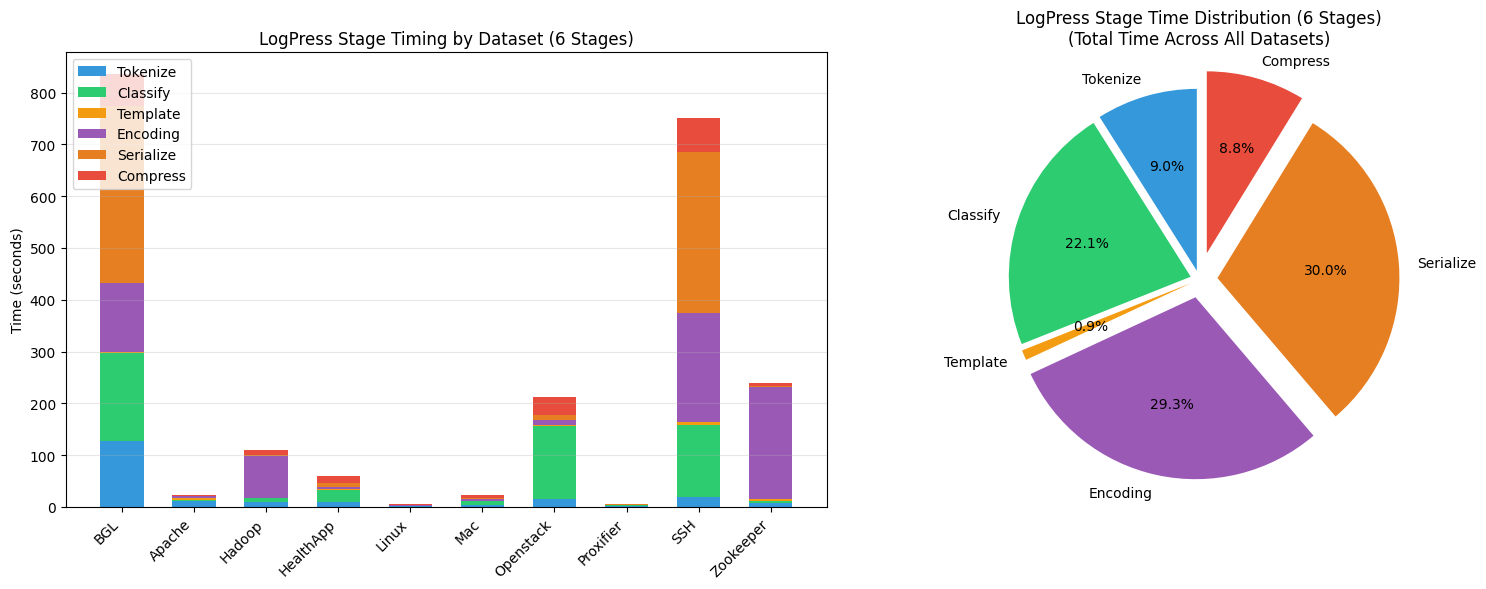

In [65]:
# Visualize LogPress stage timing breakdown

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Stacked bar chart showing stage breakdown per dataset
stage_names = ["Tokenize", "Classify", "Template", "Encoding", "Serialize", "Compress"]
stage_colors = ['#3498DB', '#2ECC71', '#F39C12', '#9B59B6', '#E67E22', '#E74C3C']

dataset_list = list(compression_results.keys())
stage_data = {
    "Tokenize": [compression_results[name]["tokenize_time"] for name in dataset_list],
    "Classify": [compression_results[name]["classify_time"] for name in dataset_list],
    "Template": [compression_results[name]["template_time"] for name in dataset_list],
    "Encoding": [compression_results[name]["encoding_time"] for name in dataset_list],
    "Serialize": [compression_results[name]["serialization_time"] for name in dataset_list],
    "Compress": [compression_results[name]["compression_time"] for name in dataset_list],
}

x = np.arange(len(dataset_list))
width = 0.6
bottom = np.zeros(len(dataset_list))

for stage, color in zip(stage_names, stage_colors):
    ax1.bar(x, stage_data[stage], width, label=stage, bottom=bottom, color=color)
    bottom += stage_data[stage]

ax1.set_ylabel("Time (seconds)")
ax1.set_title("LogPress Stage Timing by Dataset (6 Stages)")
ax1.set_xticks(x)
ax1.set_xticklabels(dataset_list, rotation=45, ha='right')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3, axis='y')

# Chart 2: Pie chart showing total time distribution across stages
total_times_per_stage = [
    total_tokenize,
    total_classify,
    total_template,
    total_encoding,
    total_serialization,
    total_compression
]

percentages = [(t / total_logpress) * 100 for t in total_times_per_stage]
explode = (0.05, 0.05, 0.05, 0.1, 0.1, 0.15)  # Emphasize last 3 stages

ax2.pie(total_times_per_stage, labels=stage_names, autopct='%1.1f%%',
        colors=stage_colors, explode=explode, startangle=90)
ax2.set_title("LogPress Stage Time Distribution (6 Stages)\n(Total Time Across All Datasets)")

plt.tight_layout()
plt.savefig('plots/logpress_stage_timing.png', dpi=300, bbox_inches='tight')
plt.show()

In [66]:
# Compression Times
print("\n\n=== Compression Times (seconds) ===\n")
print(f"{'Dataset':<12} {'Gzip':>10} {'Bzip2':>10} {'LZMA':>10} {'Zstd':>10} {'LP-Full':>10} {'LP-Compress-Only':>10}")
print("-" * 74)

compression_time_rows = []
for name, results in compression_results.items():
    row = {
        "Dataset": name,
        "Gzip": round(results["gzip_time"], 2),
        "Bzip2": round(results["bzip2_time"], 2),
        "LZMA": round(results["lzma_time"], 2),
        "Zstd": round(results["zstd_raw_time"], 2),
        "LP-Full": round(results["logpress_time"], 2),
        "LP-Zstd": round(results["zstd_only_time"], 2),
    }
    compression_time_rows.append(row)

    print(
        f"{name:<12} "
        f"{results['gzip_time']:>9.2f}s "
        f"{results['bzip2_time']:>9.2f}s "
        f"{results['lzma_time']:>9.2f}s "
        f"{results['zstd_raw_time']:>9.2f}s "
        f"{results['logpress_time']:>9.2f}s "
        f"{results['zstd_only_time']:>9.2f}s"
    )

total_times = {
    "gzip": sum(r["gzip_time"] for r in compression_results.values()),
    "bzip2": sum(r["bzip2_time"] for r in compression_results.values()),
    "lzma": sum(r["lzma_time"] for r in compression_results.values()),
    "zstd_raw": sum(r["zstd_raw_time"] for r in compression_results.values()),
    "logpress": sum(r["logpress_time"] for r in compression_results.values()),
    "zstd_only": sum(r["zstd_only_time"] for r in compression_results.values()),
}

print("-" * 74)
print(
    f"{'TOTAL':<12} "
    f"{total_times['gzip']:>9.2f}s "
    f"{total_times['bzip2']:>9.2f}s "
    f"{total_times['lzma']:>9.2f}s "
    f"{total_times['zstd_raw']:>9.2f}s "
    f"{total_times['logpress']:>9.2f}s "
    f"{total_times['zstd_only']:>9.2f}s"
)

print("\nNote: LP-Full = Full pipeline (6 stages) | LP-Zstd = Compression only (Stage 6, fair comparison)")

compression_time_rows.append(
    {
        "Dataset": "TOTAL",
        "Gzip": round(total_times["gzip"], 2),
        "Bzip2": round(total_times["bzip2"], 2),
        "LZMA": round(total_times["lzma"], 2),
        "Zstd": round(total_times["zstd_raw"], 2),
        "LP-Full": round(total_times["logpress"], 2),
        "LP-Zstd": round(total_times["zstd_only"], 2),
    }
)

# Save to CSV
df_compression_times = pd.DataFrame(compression_time_rows)
df_compression_times.to_csv(TABLES_DIR / "compression_times.csv", index=False)
print(f"\nSaved to {TABLES_DIR}/compression_times.csv")



=== Compression Times (seconds) ===

Dataset            Gzip      Bzip2       LZMA       Zstd    LP-Full LP-Compress-Only
--------------------------------------------------------------------------
BGL               5.06s      8.34s     37.84s    161.99s    836.58s     61.61s
Apache            0.09s      0.53s      0.70s      3.07s     22.61s      1.18s
Hadoop            0.40s      3.19s      4.87s     32.12s    110.72s     10.68s
HealthApp         0.82s      1.75s      7.74s     40.29s     59.55s     12.56s
Linux             0.07s      0.22s      0.56s      1.25s      5.17s      0.77s
Mac               0.21s      1.53s      2.81s     19.51s     22.13s      4.95s
Openstack         0.56s      6.50s     20.46s    114.62s    211.54s     34.07s
Proxifier         0.05s      0.31s      0.38s      1.73s      5.38s      0.73s
SSH               1.71s      6.95s     19.13s    121.78s    750.08s     65.69s
Zookeeper         0.23s      1.12s      1.69s     36.46s    240.15s      6.30s
-----------

In [67]:
# Plots Visualization of compression results

dataset_names = list(compression_results.keys())
methods = ["gzip", "bzip2", "lzma", "zstd_raw", "logpress"]
colors = ["#4A4A4A", "#1ABC9C", "#E67E22", "#3498DB", "#95A5A6"]
method_labels = ["Gzip", "Bzip2", "LZMA", "Zstd (raw)", "LogPress"]


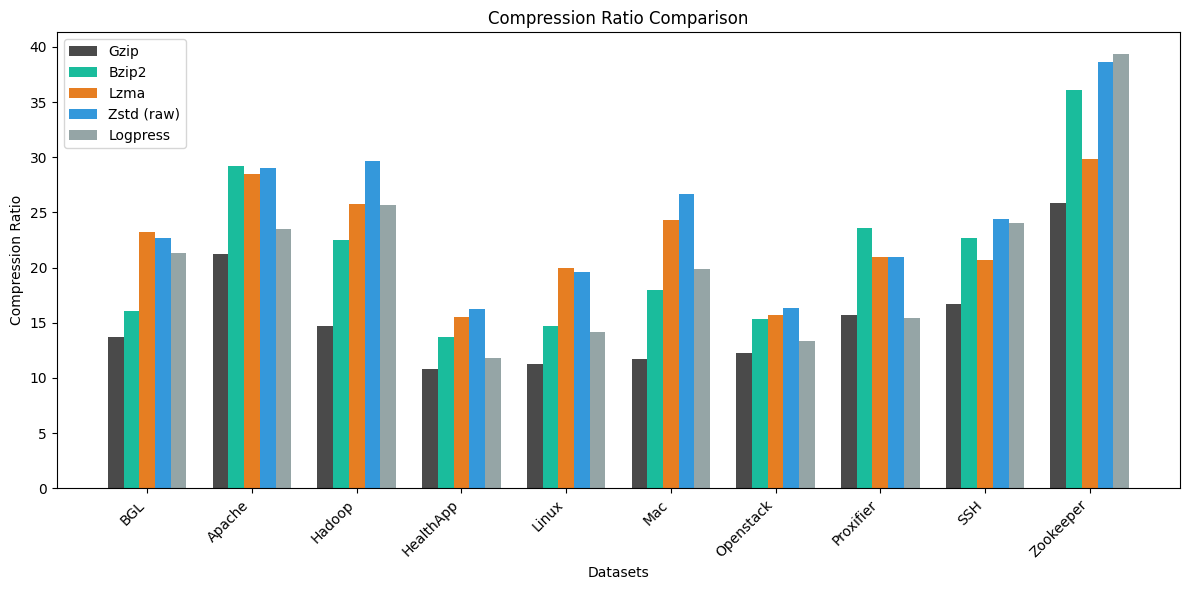

In [68]:
# Chart 1: Compression Ratios comparison

fig, ax1 = plt.subplots(figsize=(12, 6))
x = np.arange(len(dataset_names))
width = 0.15

for i, (method, color) in enumerate(zip(methods, colors)):
    ratios = [compression_results[name]["original"] / compression_results[name][method] for name in dataset_names]
    offset = (i - 2) * width
    label = "Zstd (raw)" if method == "zstd_raw" else method.capitalize()
    ax1.bar(x + offset, ratios, width, label=label, color=color)

ax1.set_xlabel("Datasets")
ax1.set_ylabel("Compression Ratio")
ax1.set_title("Compression Ratio Comparison")
ax1.set_xticks(x)
ax1.set_xticklabels(dataset_names, rotation=45, ha="right")
ax1.legend(loc="upper left")
plt.tight_layout()
plt.savefig('plots/compression_ratio_comparison.png', dpi=300, bbox_inches='tight')

plt.show()

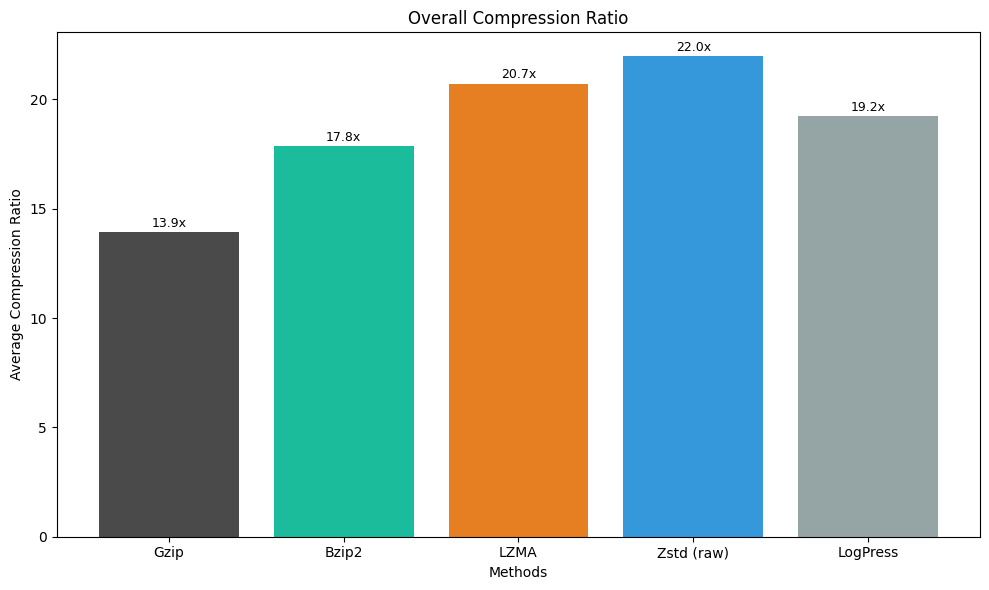

In [69]:
# Chart 2: Average compression ratio per method
fig, ax2 = plt.subplots(figsize=(10, 6))
avg_ratios = []
for method in methods:
    total_orig = sum(compression_results[name]["original"] for name in dataset_names)
    total_comp = sum(compression_results[name][method] for name in dataset_names)
    avg_ratios.append(total_orig / total_comp)

bars = ax2.bar(method_labels, avg_ratios, color=colors)
ax2.set_xlabel("Methods")
ax2.set_ylabel("Average Compression Ratio")
ax2.set_title("Overall Compression Ratio")

for bar, ratio in zip(bars, avg_ratios):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f"{ratio:.1f}x", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig('plots/compression_ratio.png', dpi=300, bbox_inches='tight')
plt.show()

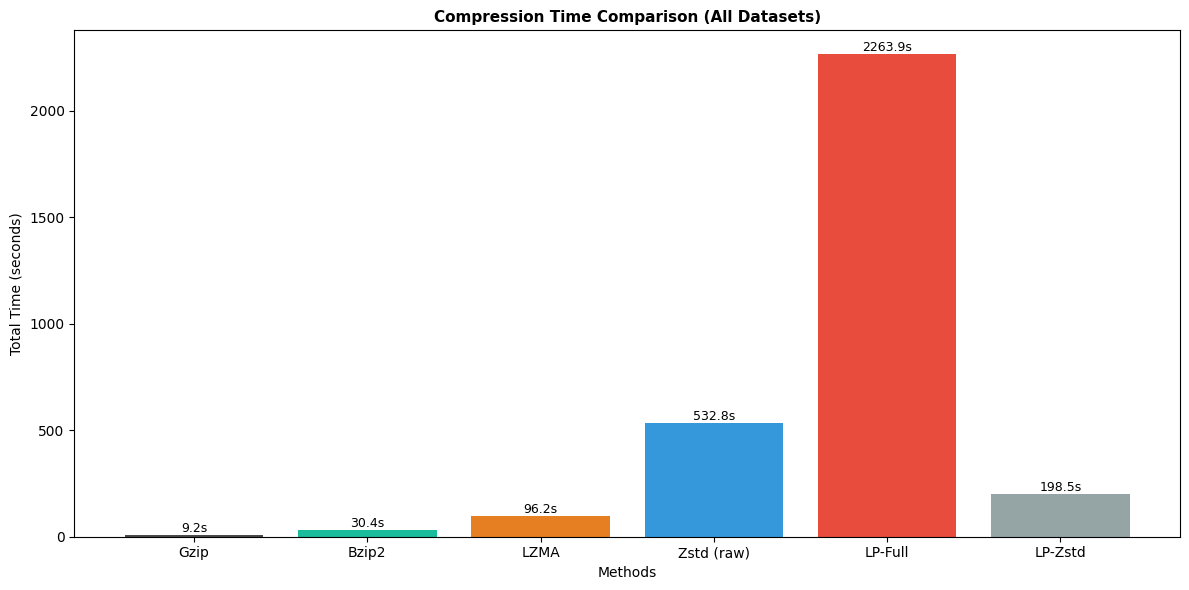

In [70]:
# Chart 3: Total compression time per method (with LP-Full vs LP-Zstd)
fig, ax3 = plt.subplots(figsize=(12, 6))

# Labels and colors for 6 methods
chart_labels = ["Gzip", "Bzip2", "LZMA", "Zstd (raw)", "LP-Full", "LP-Zstd"]
chart_colors = ["#4A4A4A", "#1ABC9C", "#E67E22", "#3498DB", "#E74C3C", "#95A5A6"]

total_times = [
    sum(compression_results[name]["gzip_time"] for name in dataset_names),
    sum(compression_results[name]["bzip2_time"] for name in dataset_names),
    sum(compression_results[name]["lzma_time"] for name in dataset_names),
    sum(compression_results[name]["zstd_raw_time"] for name in dataset_names),
    sum(compression_results[name]["logpress_time"] for name in dataset_names),
    sum(compression_results[name]["zstd_only_time"] for name in dataset_names),
]

bars = ax3.bar(chart_labels, total_times, color=chart_colors)
ax3.set_xlabel("Methods", fontsize=10)
ax3.set_ylabel("Total Time (seconds)", fontsize=10)
ax3.set_title("Compression Time Comparison (All Datasets)", fontsize=11, fontweight='bold')

for bar, t in zip(bars, total_times):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f"{t:.1f}s", ha="center", va="bottom", fontsize=9)


plt.tight_layout()
plt.savefig('plots/compression_time.png', dpi=300, bbox_inches='tight')
plt.show()

### To prove that our Compression works correctly, we verify that by simply Decompressing our .logpress files and reconstruct logs to verify our loseless compression.

In [71]:
# Load and Decompress .logpress files Function
def decompress_logpress(filepath):
    with open(filepath, "rb") as f:
        compressed = f.read()
    
    dctx = zstd.ZstdDecompressor()
    packed = dctx.decompress(compressed) 
    data = msgpack.unpackb(packed, raw=False, strict_map_key=False)
    return data

In [72]:
# Decompress separators function
def decompress_separators(compressed_sep_data): 
    sep_dict = {int(k): v for k, v in compressed_sep_data["sep_dict"].items()}
    compressed_seps = compressed_sep_data["separators"]
    
    all_separators = []
    for log_seps in compressed_seps:
        all_separators.append([sep_dict[sid] for sid in log_seps])
    
    return all_separators

In [73]:
# Decode value function - SEMANTIC DECODING
# Converts native typed values back to original string representation

def decode_value(value_tuple, id_to_path, id_to_raw):
    # SEMANTIC DECODER: Convert native typed values back to strings for reconstruction.
    #- TYPE_TS: Use stored original string
    #- TYPE_IP: Convert 32-bit integer back to dotted notation
    #- TYPE_INT: Convert integer to string
    #- TYPE_HEX: Convert integer back to hex string (with 0x prefix)
    #- TYPE_PATH: Dictionary lookup
    #- TYPE_RAW: Direct string or dictionary lookup
    val_type = value_tuple[0]
    
    if val_type == TYPE_TS:
        # Timestamp: original string stored at index 2
        return value_tuple[2]
    
    elif val_type == TYPE_IP:
        # IP: Convert 32-bit integer back to dotted notation
        ip_int = value_tuple[1]
        ip_str = int_to_ip(ip_int)
        # Check if port was stored (index 2)
        if len(value_tuple) > 2 and value_tuple[2] is not None:
            return f"{ip_str}:{value_tuple[2]}"
        return ip_str
    
    elif val_type == TYPE_PORT:
        # Port: just convert integer to string
        return str(value_tuple[1])
    
    elif val_type == TYPE_INT:
        # Integer (PID, number): convert to string
        # Check if original format was preserved (for leading zeros)
        if len(value_tuple) > 2:
            return value_tuple[2]  # Original string with leading zeros
        # Handle case where large int was converted to string by prepare_for_msgpack
        return str(value_tuple[1])
    
    elif val_type == TYPE_HEX:
        # Hex: use original string if stored, else convert back
        if len(value_tuple) > 2:
            return value_tuple[2]  # Original string preserved
        val = value_tuple[1]
        if isinstance(val, str): 
            return val
        return hex(val)
    
    elif val_type == TYPE_PATH:
        # Path: dictionary lookup
        return id_to_path.get(value_tuple[1], str(value_tuple[1]))
    
    elif val_type == TYPE_RAW:
        # Raw: could be direct string or dict ID with original
        if len(value_tuple) > 2:
            return value_tuple[2]  # Original string stored
        elif isinstance(value_tuple[1], str):
            return value_tuple[1]
        else:
            return id_to_raw.get(value_tuple[1], str(value_tuple[1]))
    
    elif val_type == TYPE_UUID:
        # UUID: stored as string, return directly
        return value_tuple[1]
    
    elif val_type == TYPE_MAC:
        # MAC: original format stored at index 2 for reconstruction
        if len(value_tuple) > 2:
            return value_tuple[2]
        # Fallback: convert integer back to MAC format
        mac_int = value_tuple[1]
        mac_hex = f"{mac_int:012X}"
        return ':'.join(mac_hex[i:i+2] for i in range(0, 12, 2))
    
    elif val_type == TYPE_KV:
        # Key=Value: reconstruct from key and value parts
        return f"{value_tuple[1]}={value_tuple[2]}"
    
    else:

        return str(value_tuple[1])

In [74]:
# Reconstruct log function 
def reconstruct_log(template_tokens, values, separators, id_to_path, id_to_raw):
    decoded_tokens = []
    value_idx = 0
    
    for token in template_tokens:
        if token.startswith("<*") and token.endswith("*>"):
            if value_idx < len(values):
                decoded = decode_value(values[value_idx], id_to_path, id_to_raw)
                decoded_tokens.append(decoded)
                value_idx += 1
            else:
                decoded_tokens.append(token)
        else:
            decoded_tokens.append(token)
    
    result = []
    for i, token in enumerate(decoded_tokens):
        if i < len(separators):
            result.append(separators[i])
        result.append(token)
    
    if len(separators) > len(decoded_tokens):
        result.append(separators[len(decoded_tokens)])

    return "".join(result)

In [75]:
OUTPUT_DIR = Path("compressed")
OUTPUT_DIR.mkdir(exist_ok=True)


print("\nVerifying compression correctness by reconstructing all logs...\n")

verification_results = {}
verification_rows = []

print(f"{'Dataset':<12} {'Total Logs':>12} {'Matched':>12} {'Mismatched':>12} {'Match Rate':>12}")
print("-" * 64)

for name in datasets.keys():
    filepath = OUTPUT_DIR / f"{name}.logpress"
    if not filepath.exists():
        print(f"{name:<12} {'FILE MISSING':>12}")
        continue
    
    # Load compressed data
    decompressed = decompress_logpress(filepath)
    id_to_template = decompress_templates(decompressed["templates"])
    all_separators = decompress_separators(decompressed["separators"])
    
    # Convert string keys back to integers for dictionaries (only path and raw now)
    id_to_path = {int(k): v for k, v in decompressed.get("id_to_path", {}).items()}
    id_to_raw = {int(k): v for k, v in decompressed.get("id_to_raw", {}).items()}
    
    # Verify reconstruction for all logs
    original_logs = datasets[name]
    match_count = 0
    mismatch_examples = []
    
    for i in range(len(original_logs)):
        original = original_logs[i]
        template_id = decompressed["template_ids"][i]
        template = id_to_template[template_id]
        values = decompressed["values"][i]
        seps = all_separators[i]
        
        reconstructed = reconstruct_log(template, values, seps, id_to_path, id_to_raw)
        
        if original == reconstructed:
            match_count += 1
        elif len(mismatch_examples) < 3:  # Store first 3 mismatches for debugging
            mismatch_examples.append((i, original, reconstructed))
    
    total_logs = len(original_logs)
    mismatch_count = total_logs - match_count
    match_rate = 100 * match_count / total_logs
    
    verification_results[name] = {
        "total": total_logs,
        "matched": match_count,
        "mismatched": mismatch_count,
        "rate": match_rate,
        "examples": mismatch_examples,
    }
    
    verification_rows.append({
        "Dataset": name,
        "Total Logs": total_logs,
        "Matched": match_count,
        "Mismatched": mismatch_count,
        "Match Rate (%)": round(match_rate, 2)
    })
    
    # Print result
    status = "✓" if match_rate == 100 else "✗"
    print(f"{name:<12} {total_logs:>12,} {match_count:>12,} {mismatch_count:>12,} {match_rate:>11.2f}% {status}")

# Summary
print("-" * 64)
total_all_logs = sum(r["total"] for r in verification_results.values())
total_matched = sum(r["matched"] for r in verification_results.values())
total_mismatched = sum(r["mismatched"] for r in verification_results.values())
overall_rate = 100 * total_matched / total_all_logs if total_all_logs > 0 else 0

print(f"{'TOTAL':<12} {total_all_logs:>12,} {total_matched:>12,} {total_mismatched:>12,} {overall_rate:>11.2f}%")

verification_rows.append({
    "Dataset": "TOTAL",
    "Total Logs": total_all_logs,
    "Matched": total_matched,
    "Mismatched": total_mismatched,
    "Match Rate (%)": round(overall_rate, 2)
})

# Save to CSV
df_verification = pd.DataFrame(verification_rows)
df_verification.to_csv(TABLES_DIR / "verification_results.csv", index=False)
print(f"\nSaved to {TABLES_DIR}/verification_results.csv")


Verifying compression correctness by reconstructing all logs...

Dataset        Total Logs      Matched   Mismatched   Match Rate
----------------------------------------------------------------
BGL               826,284      826,284            0      100.00% ✓
Apache             51,978       51,978            0      100.00% ✓
Hadoop            179,993      179,993            0      100.00% ✓
HealthApp         253,395      253,395            0      100.00% ✓
Linux              25,567       25,567            0      100.00% ✓
Mac               117,283      117,283            0      100.00% ✓
Openstack         189,386      189,386            0      100.00% ✓
Proxifier          21,320       21,320            0      100.00% ✓
SSH               655,147      655,147            0      100.00% ✓
Zookeeper          74,273       74,273            0      100.00% ✓
----------------------------------------------------------------
TOTAL           2,394,626    2,394,626            0      100.00%

Sav

### Query Engine
Query compressed logs using lazy reconstruction:
    - Metadata decompression where we load the .logpress file, decompress the entire file with zstd, read msgpack to get structured metadata (template IDs, encoded values, dictionaries)
    - Query works directly on those sturctured metadata (template IDs, severity codes, IP dictionary IDs) without reconstructing any log. 
    - Only Matching logs are reconstructed.  


In [76]:
# Load and decompressed LogPress Function
# Returns a dict with all data needed for queries.
def load_logpress(filepath):
    start = time.time()
    
    # Decompress file
    with open(filepath, "rb") as f:
        compressed = f.read()
    
    dctx = zstd.ZstdDecompressor()
    packed = dctx.decompress(compressed)
    data = msgpack.unpackb(packed, raw=False, strict_map_key=False)
    
    # Decompress templates and separators
    id_to_template = decompress_templates(data["templates"])
    all_separators = decompress_separators(data["separators"])
    
    # Build dictionaries (only path and raw now - IPs are native integers)
    id_to_path = {int(k): v for k, v in data.get("id_to_path", {}).items()}
    id_to_raw = {int(k): v for k, v in data.get("id_to_raw", {}).items()}
    
    load_time = time.time() - start
    
    return {
        "template_ids": data["template_ids"],
        "values": data["values"],
        "id_to_template": id_to_template,
        "all_separators": all_separators,
        "id_to_path": id_to_path,
        "id_to_raw": id_to_raw,
        "num_logs": len(data["template_ids"]),
        "load_time": load_time,
    }


# Helper to extract unique IPs from values (now stored as integers)
def get_unique_ips_from_data(data):
    #Extract IP addresses from semantically encoded values. 
    unique_ips = set()
    for vals in data['values']:
        for v in vals:
            if v[0] == TYPE_IP:
                unique_ips.add(v[1])  # IP stored as integer
    return unique_ips

In [77]:
# Query logs function (by severity, IP, template keyword, template ID) 
def query_logs(data, severity=None, ip=None, template_keyword=None, template_id=None, reconstruct=False, limit=None):

    # Start with all log indices
    candidates = set(range(data["num_logs"]))
    
    # Filter by severity
    if severity:
        sev_lower = severity.lower()
        # Find templates containing the severity keyword
        matching_tids = {tid for tid, tmpl in data["id_to_template"].items()
                        if any(sev_lower in token.lower() for token in tmpl)}
        severity_matches = {idx for idx, tid in enumerate(data["template_ids"]) 
                          if tid in matching_tids}
        candidates &= severity_matches
    
    # Filter by IP - SEMANTIC: Handle both string and integer IP inputs
    if ip is not None:
        # If IP is already an integer (from get_unique_ips_from_data), use it directly
        if isinstance(ip, int):
            ip_int = ip
        else:
            # If IP is a string, convert it to integer
            ip_int = ip_to_int(ip)
        
        if ip_int is None:
            candidates = set()
        else:
            # Match logs containing this IP as native integer
            ip_matches = {idx for idx, vals in enumerate(data["values"])
                if any(v[0] == TYPE_IP and v[1] == ip_int for v in vals)}
            candidates &= ip_matches
    
    # Filter by template keyword
    if template_keyword:
        matching_tids = {tid for tid, tmpl in data["id_to_template"].items()
                if template_keyword.lower() in " ".join(tmpl).lower()}
        template_matches = {idx for idx, tid in enumerate(data["template_ids"]) 
                if tid in matching_tids}
        candidates &= template_matches
    
    # Filter by specific template ID
    if template_id is not None:
        template_matches = {idx for idx, tid in enumerate(data["template_ids"]) 
                if tid == template_id}
        candidates &= template_matches
    
    # Sort and limit results
    result_indices = sorted(candidates)
    if limit:
        result_indices = result_indices[:limit]
    
    # Return indices or reconstructed logs
    if not reconstruct:
        return result_indices
    
    # Reconstruct matching logs
    logs = []
    for idx in result_indices:
        template = data["id_to_template"][data["template_ids"][idx]]
        log = reconstruct_log(
            template, 
            data["values"][idx], 
            data["all_separators"][idx],
            data["id_to_path"], 
            data["id_to_raw"]
        )
        logs.append(log)
    
    return logs

### Query Performance Benchmarking

Test query performance with various query types to demonstrate lazy reconstruction benefits.

In [78]:
# Query Performance Benchmark
# Load all compressed datasets and benchmark query operations

all_data = {}
load_times = {}

print("Loading compressed datasets for querying...\n")
for name in datasets.keys():
    filepath = OUTPUT_DIR / f"{name}.logpress"
    if not filepath.exists():
        continue
    
    t_load = time.time()
    data = load_logpress(filepath)
    load_times[name] = time.time() - t_load
    all_data[name] = data
    
    print(f"{name:<12} loaded in {load_times[name]:.3f}s ({len(data['template_ids']):,} logs)")

print(f"\nTotal load time: {sum(load_times.values()):.2f}s")
print(f"Average load time: {sum(load_times.values()) / len(load_times):.2f}s per dataset")

Loading compressed datasets for querying...

BGL          loaded in 10.208s (826,284 logs)
Apache       loaded in 0.126s (51,978 logs)
Hadoop       loaded in 0.445s (179,993 logs)
HealthApp    loaded in 7.434s (253,395 logs)
Linux        loaded in 0.061s (25,567 logs)
Mac          loaded in 0.320s (117,283 logs)
Openstack    loaded in 1.031s (189,386 logs)
Proxifier    loaded in 0.052s (21,320 logs)
SSH          loaded in 73.773s (655,147 logs)
Zookeeper    loaded in 0.193s (74,273 logs)

Total load time: 93.64s
Average load time: 9.36s per dataset


In [79]:
# Query Benchmarks: Test different query types

query_results = {}

print("\nQuery Performance Benchmarking \n")

# Query Type 1: Severity filtering
print("Query Type 1: Severity-based filtering")
print(f"{'Dataset':<12} {'Query Time':>12} {'Matches':>12} {'Logs/sec':>12}")
print("-" * 52)

severity_times = []
for name, data in all_data.items():
    t_query = time.time()
    matches = query_logs(data, severity="error", reconstruct=False, limit=None)
    query_time = time.time() - t_query
    severity_times.append((name, query_time, len(matches)))
    logs_per_sec = data['num_logs'] / query_time if query_time > 0 else 0
    print(f"{name:<12} {query_time*1000:>11.2f}ms {len(matches):>12,} {logs_per_sec:>11,.0f}")

print()

# Query Type 2: Template keyword filtering  
print("Query Type 2: Template keyword filtering")
print(f"{'Dataset':<12} {'Query Time':>12} {'Matches':>12} {'Logs/sec':>12}")
print("-" * 52)

keyword_times = []
for name, data in all_data.items():
    t_query = time.time()
    matches = query_logs(data, template_keyword="failed", reconstruct=False, limit=None)
    query_time = time.time() - t_query
    keyword_times.append((name, query_time, len(matches)))
    logs_per_sec = data['num_logs'] / query_time if query_time > 0 else 0
    print(f"{name:<12} {query_time*1000:>11.2f}ms {len(matches):>12,} {logs_per_sec:>11,.0f}")

print()

# Query Type 3: Specific template ID
print("Query Type 3: Specific template ID lookup")
print(f"{'Dataset':<12} {'Query Time':>12} {'Matches':>12} {'Logs/sec':>12}")
print("-" * 52)

template_times = []
for name, data in all_data.items():
    # Query for most common template (template ID 0)
    t_query = time.time()
    matches = query_logs(data, template_id=0, reconstruct=False, limit=None)
    query_time = time.time() - t_query
    template_times.append((name, query_time, len(matches)))
    logs_per_sec = data['num_logs'] / query_time if query_time > 0 else 0
    print(f"{name:<12} {query_time*1000:>11.2f}ms {len(matches):>12,} {logs_per_sec:>11,.0f}")

print()

# Query Type 4: IP address filtering (for datasets with IPs)
print("Query Type 4: IP address filtering")
print(f"{'Dataset':<12} {'Query Time':>12} {'Matches':>12} {'Logs/sec':>12}")
print("-" * 52)

ip_times = []
for name, data in all_data.items():
    # Get all unique IPs from the dataset
    unique_ips = get_unique_ips_from_data(data)
    
    if unique_ips:
        # Test with first IP
        test_ip = list(unique_ips)[0]
        t_query = time.time()
        matches = query_logs(data, ip=test_ip, reconstruct=False, limit=None)
        query_time = time.time() - t_query
        ip_times.append((name, query_time, len(matches)))
        logs_per_sec = data['num_logs'] / query_time if query_time > 0 else 0
        print(f"{name:<12} {query_time*1000:>11.2f}ms {len(matches):>12,} {logs_per_sec:>11,.0f}")
    else:
        print(f"{name:<12} {'N/A (no IPs)':>12} {'-':>12} {'-':>12}")

print()

# Query Type 5: Reconstruction benchmark
print("Query Type 5: Lazy reconstruction (reconstruct 100 matching logs)")
print(f"{'Dataset':<12} {'Query Time':>12} {'Reconstructed':>14} {'Logs/sec':>12}")
print("-" * 56)

reconstruct_times = []
for name, data in all_data.items():
    t_query = time.time()
    logs = query_logs(data, template_id=0, reconstruct=True, limit=100)
    query_time = time.time() - t_query
    reconstruct_times.append((name, query_time, len(logs)))
    logs_per_sec = len(logs) / query_time if query_time > 0 else 0
    print(f"{name:<12} {query_time*1000:>11.2f}ms {len(logs):>14,} {logs_per_sec:>11,.0f}")

# Store results
query_results = {
    "severity": severity_times,
    "keyword": keyword_times,
    "template_id": template_times,
    "ip": ip_times,
    "reconstruct": reconstruct_times,
    "load_times": load_times
}


Query Performance Benchmarking 

Query Type 1: Severity-based filtering
Dataset        Query Time      Matches     Logs/sec
----------------------------------------------------
BGL               518.80ms      209,156   1,592,674
Apache             18.85ms       38,055   2,757,789
Hadoop             46.71ms          591   3,853,532
HealthApp          69.39ms          222   3,651,635
Linux               3.08ms           21   8,305,125
Mac                35.19ms       10,051   3,332,840
Openstack         215.66ms          194     878,171
Proxifier           4.20ms          881   5,070,168
SSH                65.43ms        1,127  10,013,650
Zookeeper           5.14ms       11,028  14,439,767

Query Type 2: Template keyword filtering
Dataset        Query Time      Matches     Logs/sec
----------------------------------------------------
BGL               196.28ms        5,645   4,209,716
Apache              5.73ms           53   9,076,250
Hadoop             35.29ms        5,445   5,100,396

In [80]:
# Query Performance Summary Table

print("\n\nQuery Performance Summary \n")

# Calculate average query times per type
query_types = ["Severity", "Keyword", "Template ID", "IP Address", "Reconstruct (100)"]
avg_times_ms = []

for query_type_key in ["severity", "keyword", "template_id", "ip", "reconstruct"]:
    times = [t[1] * 1000 for t in query_results[query_type_key] if t[1] > 0]  # Convert to ms
    avg_time = sum(times) / len(times) if times else 0
    avg_times_ms.append(avg_time)

print(f"{'Query Type':<25} {'Avg Time':>12}")
print("-" * 39)
for query_type, avg_time in zip(query_types, avg_times_ms):
    print(f"{query_type:<25} {avg_time:>10.2f}ms")

# Save query benchmark results
query_benchmark_rows = []
for name in all_data.keys():
    row = {"Dataset": name}
    
    # Find timing for this dataset in each query type
    for qtype_key, qtype_name in [("severity", "Severity_ms"), ("keyword", "Keyword_ms"), 
                                    ("template_id", "TemplateID_ms"), ("ip", "IP_ms"), 
                                    ("reconstruct", "Reconstruct_ms")]:
        time_entry = next((t for t in query_results[qtype_key] if t[0] == name), None)
        if time_entry:
            row[qtype_name] = round(time_entry[1] * 1000, 2)  # Convert to ms
        else:
            row[qtype_name] = None
    
    row["Load_Time_s"] = round(query_results["load_times"][name], 2)
    query_benchmark_rows.append(row)

df_query_benchmark = pd.DataFrame(query_benchmark_rows)
df_query_benchmark.to_csv(TABLES_DIR / "query_performance.csv", index=False)
print(f"\nSaved to {TABLES_DIR}/query_performance.csv")


print(f"• Metadata loading: {sum(query_results['load_times'].values()):.2f}s total")
print(f"• Average severity query: {avg_times_ms[0]:.2f}ms ")
print(f"• Average template lookup: {avg_times_ms[2]:.2f}ms (direct ID access)")
print(f"• Lazy reconstruction enables selective decompression without processing all logs")



Query Performance Summary 

Query Type                    Avg Time
---------------------------------------
Severity                       98.25ms
Keyword                        45.19ms
Template ID                    21.14ms
IP Address                    110.56ms
Reconstruct (100)              20.64ms

Saved to tables/query_performance.csv
• Metadata loading: 93.64s total
• Average severity query: 98.25ms 
• Average template lookup: 21.14ms (direct ID access)
• Lazy reconstruction enables selective decompression without processing all logs


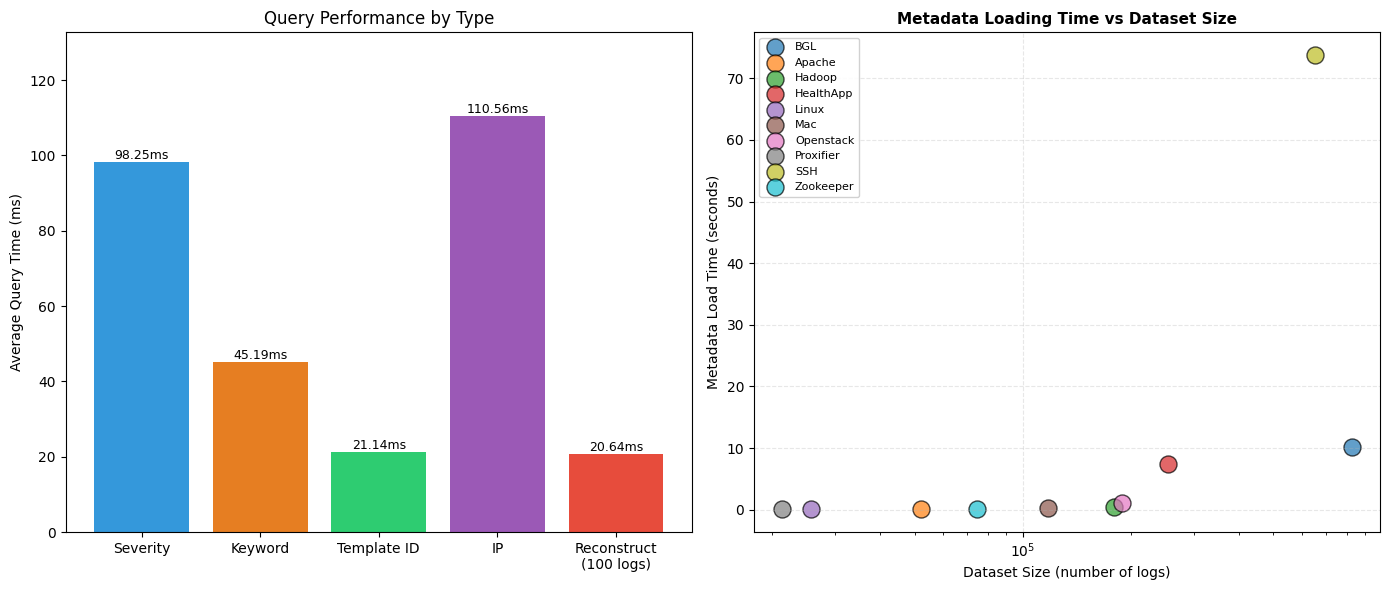

In [81]:
# Visualize query performance

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Average query times by type
query_type_labels = ["Severity", "Keyword", "Template ID", "IP", "Reconstruct\n(100 logs)"]
colors = ['#3498DB', '#E67E22', '#2ECC71', '#9B59B6', '#E74C3C']

bars = ax1.bar(query_type_labels, avg_times_ms, color=colors)
ax1.set_ylabel("Average Query Time (ms)")
ax1.set_title("Query Performance by Type")
ax1.set_ylim(0, max(avg_times_ms) * 1.2)

# Add value labels on bars
for bar, time_ms in zip(bars, avg_times_ms):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height,
             f'{time_ms:.2f}ms', ha='center', va='bottom', fontsize=9)

# Chart 2: Load time vs dataset size
dataset_sizes = [all_data[name]['num_logs'] for name in all_data.keys()]
load_time_list = [query_results['load_times'][name] for name in all_data.keys()]
dataset_labels = list(all_data.keys())

# Plot each dataset with different colors and add to legend
scatter_colors = plt.cm.tab10(np.linspace(0, 1, len(dataset_labels)))
for i, name in enumerate(dataset_labels):
    ax2.scatter(dataset_sizes[i], load_time_list[i], s=150, alpha=0.7, 
               c=[scatter_colors[i]], edgecolors='black', linewidth=1, label=name)

ax2.set_xlabel("Dataset Size (number of logs)", fontsize=10)
ax2.set_ylabel("Metadata Load Time (seconds)", fontsize=10)
ax2.set_title("Metadata Loading Time vs Dataset Size", fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xscale('log')  # Log scale for better visibility of size differences
ax2.legend(loc='upper left', fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.savefig('plots/query_performance.png', dpi=300, bbox_inches='tight')
plt.show()